# Exploring Oakland Business Data: Data Axle vs. Business License Corridors

This notebook is the first step toward building a **canonical Oakland business database** that
eventually combines three sources: **Data Axle**, the City's **business-license** data, and
(later) **Dun & Bradstreet (D&B)**. Before any entity resolution / fuzzy joining happens, we need
to understand each source on its own terms.

Two files are compared here:

- `data/business/Business License Corridors_050825.xlsx` — an extract from Oakland's business
  license system (referred to below as **BL**).
- `data/business/Oakland_DataAxleV2.xlsx` — a commercial business-information product
  (referred to below as **DA**, or "Data Axle").

We also bring in two existing corridor/BID shapefiles for context:

- `data/corridors/OAK_BIDs/OAK_BIDs.shp`
- `data/corridors/Policy_Polygons/Policy_Polygons.shp`

**Important framing:** neither business dataset is "ground truth," and the corridor shapefiles are
known to be an *incomplete* picture of Oakland commercial activity. The goal of this notebook is
descriptive: understand what each source represents, where they agree or disagree, how reliably
they can be linked, and what open questions remain before D&B is folded in.

**How to read this notebook:** each numbered section corresponds to a step in the analysis plan.
Code cells are kept small and single-purpose; every substantial output is followed by a short
"takeaway" note. Nothing here is a final entity-resolution pipeline — it is exploratory groundwork.

In [1]:
import re
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from shapely.geometry import Point
from tqdm.notebook import tqdm

try:
    from rapidfuzz import fuzz, process
    HAS_RAPIDFUZZ = True
except ImportError:
    HAS_RAPIDFUZZ = False

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
plt.rcParams["figure.facecolor"] = "white"
tqdm.pandas()

/home/aniket/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
# ---- source files -----------------------------------------------------
BL_PATH = "../../data/business/Business License Corridors_050825.xlsx"
DA_PATH = "../../data/business/Oakland_DataAxleV2.xlsx"
BID_PATH = "../../data/corridors/OAK_BIDs/OAK_BIDs.shp"
PP_PATH = "../../data/corridors/Policy_Polygons/Policy_Polygons.shp"

# ---- the subset of Data Axle's ~380 columns that matter for this project ----
DA_RELEVANT_COLS = [
    "Company Name", "Address", "City", "State", "ZIP Code", "Neighborhood",
    "Latitude", "Longitude",
    "Primary NAICS", "Primary NAICS Description",
    "Primary SIC Code", "Primary SIC Description",
    "Location Type", "Type of Business", "Home Business",
    "Location Employee Size Range", "Location Employee Size Actual",
    "Location Sales Volume Range", "Location Sales Volume Actual",
    "Year Established", "Years In Database",
    "Franchise Description 1", "Affiliated Records", "Affiliated Locations",
    "Square Footage", "Credit Score Alpha",
    "Own or Lease", "Firm or Individual", "Government Office",
]

# ---- rough Oakland geographic extent, used only to flag likely bad geocodes ----
OAK_LAT_RANGE = (37.60, 37.90)
OAK_LON_RANGE = (-122.36, -122.10)

# ---- local projected CRS for distance calculations (NAD83 / UTM zone 10N, meters) ----
LOCAL_CRS = "EPSG:26910"

# ---- broad-sector grouping, keyed on the first 2 digits of a NAICS code ----
NAICS2_TO_SECTOR = {
    "11": "Other / Unclassified", "21": "Other / Unclassified", "22": "Other / Unclassified",
    "23": "Construction",
    "31": "Manufacturing", "32": "Manufacturing", "33": "Manufacturing",
    "42": "Wholesale Trade",
    "44": "Retail Trade", "45": "Retail Trade",
    "48": "Transportation & Warehousing", "49": "Transportation & Warehousing",
    "51": "Other / Unclassified",
    "52": "Finance, Insurance & Real Estate", "53": "Finance, Insurance & Real Estate",
    "54": "Professional, Scientific & Technical Services",
    "55": "Other / Unclassified",
    "56": "Administrative & Support Services",
    "61": "Education",
    "62": "Health Care & Social Assistance",
    "71": "Arts, Entertainment & Recreation",
    "72": "Accommodation & Food Services",
    "81": "Other Services",
    "92": "Public / Institutional",
    "99": "Other / Unclassified",
}

# ---- street-address normalization tables ----
STREET_SUFFIX_MAP = {
    "STREET": "ST", "AVENUE": "AVE", "BOULEVARD": "BLVD", "DRIVE": "DR", "ROAD": "RD",
    "LANE": "LN", "PLACE": "PL", "COURT": "CT", "CIRCLE": "CIR", "TERRACE": "TER",
    "PARKWAY": "PKWY", "HIGHWAY": "HWY", "SQUARE": "SQ", "TRAIL": "TRL", "WAY": "WAY",
    "ALLEY": "ALY",
}
DIRECTION_MAP = {"NORTH": "N", "SOUTH": "S", "EAST": "E", "WEST": "W"}
UNIT_MARKER_TOKENS = {
    "#", "STE", "SUITE", "UNIT", "APT", "BLDG", "BUILDING", "NO", "RM", "ROOM", "FL",
    "FLOOR", "PMB",
}
STREET_SUFFIX_TOKENS = set(STREET_SUFFIX_MAP.values())

# ---- proximity thresholds (meters) used when summarizing spatial match quality ----
DISTANCE_THRESHOLDS_M = [10, 25, 50, 100]

RNG_SEED = 42

## 1. Load and Inspect the Datasets

We start by loading both files in full and looking at their raw shape, before deciding which
columns actually matter. Data Axle in particular ships with ~380 columns (mostly executive contact
info, expense estimates, and open-hours fields that are not relevant here), so we inspect the full
frame once and then work with a trimmed, explicitly-named subset for everything downstream.

In [3]:
bl_raw = pd.read_excel(BL_PATH)
print("Business License (BL) raw shape:", bl_raw.shape)
bl_raw.head()

Business License (BL) raw shape: (46514, 6)


,Bus address,"Bus City, State",NAICS6D,NAICS6D_Desc,LON,LAT
0,3775 ALAMEDA AVE STE B,"OAKLAND, CA 94601-3921",484110.0,"General Freight Trucking, Local",-122.223323,37.768064
1,7201 EARHART RD,"OAKLAND, CA 94621-4507",492110.0,Couriers,-122.216631,37.736097
2,1707 WOOD ST,"OAKLAND, CA 94607-1623",485999.0,All Other Transit and Ground Passenger Transp...,-122.295654,37.816101
3,530 WATER ST,"OAKLAND, CA 94607-3524",484110.0,"General Freight Trucking, Local",-122.275737,37.793997
4,737 BAY ST,"OAKLAND, CA 94607-1100",484110.0,"General Freight Trucking, Local",-122.306814,37.807068


The business-license extract is strikingly minimal: **six columns**, with no business name field
at all. It gives us an address, a city/state/ZIP string, a NAICS code + description, and a
lat/lon pair. This alone is an important constraint on everything that follows — we cannot do
name-based matching against this source, and every "business" in BL is really just an
address + NAICS-code record.

In [4]:
print("BL columns:", bl_raw.columns.tolist())
print()
print(bl_raw.dtypes)

BL columns: ['Bus address', 'Bus City, State', 'NAICS6D', 'NAICS6D_Desc', 'LON', 'LAT']

Bus address         object
Bus City, State     object
NAICS6D            float64
NAICS6D_Desc        object
LON                float64
LAT                float64
dtype: object


In [5]:
print("BL duplicate rows (all columns identical):", bl_raw.duplicated().sum())
print()
print("BL missingness by column (%):")
print((bl_raw.isna().mean() * 100).round(2))

BL duplicate rows (all columns identical): 1086

BL missingness by column (%):
Bus address         0.00
Bus City, State     0.00
NAICS6D             8.55
NAICS6D_Desc       51.58
LON                 1.24
LAT                 1.24
dtype: float64


Now the Data Axle file. We read the full ~380-column sheet once for inspection, then build a
much smaller working frame (`DA_RELEVANT_COLS`, defined in the constants cell above) for the rest
of the notebook.

In [6]:
da_raw = pd.read_excel(DA_PATH)
print("Data Axle (DA) raw shape:", da_raw.shape)

Data Axle (DA) raw shape: (29545, 383)


In [7]:
print(f"DA has {da_raw.shape[1]} columns total. Sample of column names:")
print(da_raw.columns.tolist()[:40], "...")

DA has 383 columns total. Sample of column names:
['Company Name', 'Parent Company Name', 'Executive First Name', 'Executive Last Name', 'Professional Title', 'Executive Title', 'Executive Gender', 'Address', 'City', 'State', 'ZIP Code', 'ZIP Four', 'Carrier Route', 'Delivery Point Barcode', 'County', 'Metro Area', 'Neighborhood', 'Phone Number Combined', 'Fax Number Combined', 'Toll Free Number Combined', 'Website', 'Company Description', 'Primary SIC Code', 'Primary SIC Description', 'Primary SIC Ad Size', 'Primary SIC Year Appeared', 'SIC Code 1', 'SIC Code 1 Description', 'SIC Code 1 Ad Size', 'SIC Code 1 Year Appeared', 'SIC Code 2', 'SIC Code 2 Description', 'SIC Code 2 Ad Size', 'SIC Code 2 Year Appeared', 'SIC Code 3', 'SIC Code 3 Description', 'SIC Code 3 Ad Size', 'SIC Code 3 Year Appeared', 'SIC Code 4', 'SIC Code 4 Description'] ...


Printing all ~380 columns is not useful here. Instead, the table below documents the subset we
identified as relevant to this project, matched to the exact field names present in the file.

In [8]:
da_field_notes = pd.DataFrame([
    ("Company Name", "business name"),
    ("Address / City / State / ZIP Code", "street address fields"),
    ("Neighborhood", "Data-Axle-assigned neighborhood label"),
    ("Latitude / Longitude", "coordinates"),
    ("Primary NAICS / Primary NAICS Description", "primary industry classification"),
    ("Primary SIC Code / Primary SIC Description", "legacy SIC classification"),
    ("Location Type", "single loc / branch / headquarter / subsidiary"),
    ("Type of Business", "private / public / branch-of-public-company"),
    ("Home Business", "Yes/No home-based indicator"),
    ("Location Employee Size Range / Actual", "employee count at this location"),
    ("Location Sales Volume Range / Actual", "estimated sales at this location"),
    ("Year Established", "year the business reports it was founded"),
    ("Years In Database", "years Data Axle has tracked this record"),
    ("Franchise Description 1", "franchise/specialty tag (see Section 4 caveat)"),
    ("Affiliated Records / Affiliated Locations", "counts of related DA records, multi-location indicator"),
    ("Square Footage", "binned facility size"),
    ("Credit Score Alpha", "letter-grade credit indicator"),
    ("Own or Lease", "occupancy status"),
    ("Firm or Individual", "coded firm-type flag"),
    ("Government Office", "coded government-use flag"),
], columns=["Field(s)", "Why it matters here"])
da_field_notes

,Field(s),Why it matters here
0,Company Name,business name
1,Address / City / State / ZIP Code,street address fields
2,Neighborhood,Data-Axle-assigned neighborhood label
3,Latitude / Longitude,coordinates
4,Primary NAICS / Primary NAICS Description,primary industry classification
5,Primary SIC Code / Primary SIC Description,legacy SIC classification
6,Location Type,single loc / branch / headquarter / subsidiary
7,Type of Business,private / public / branch-of-public-company
8,Home Business,Yes/No home-based indicator
9,Location Employee Size Range / Actual,employee count at this location


In [9]:
da = da_raw[DA_RELEVANT_COLS].copy()
print("Trimmed DA working frame:", da.shape)
da.head()

Trimmed DA working frame: (29545, 29)


,Company Name,Address,City,State,ZIP Code,Neighborhood,Latitude,Longitude,Primary NAICS,Primary NAICS Description,Primary SIC Code,Primary SIC Description,Location Type,Type of Business,Home Business,Location Employee Size Range,Location Employee Size Actual,Location Sales Volume Range,Location Sales Volume Actual,Year Established,Years In Database,Franchise Description 1,Affiliated Records,Affiliated Locations,Square Footage,Credit Score Alpha,Own or Lease,Firm or Individual,Government Office
0,0-90 Health & Human Servicing,7957- Greenly Drive Oakland CA,Oakland,CA,94605,Eastmont Hills,37.769000,-122.157748,99999004,Unclassified Establishments,999977,Nonclassified Establishments,Single Loc,Private,Yes,NaN,0,NaN,$0,NaN,3,NaN,0,0,"1,500 - 2,499",U,Unknown,2,0
1,1 Seafood & Chicken Restaurant,4014 Macarthur Blvd,Oakland,CA,94619,Upper Laurel,37.790435,-122.197222,44525004,Fish And Seafood Retailers,542101,Seafood-Retail,Single Loc,Private,No,1 to 4,4,"$500,000-1 Million","$717,000",NaN,19,NaN,0,0,"2,500 - 4,999",B+,Own,2,0
2,10-4 Tow Of Oakland,1409 35th Ave # 94601,Oakland,CA,94601,Saint Elizabeth,37.776516,-122.222874,48841002,Motor Vehicle Towing,754905,Towing-Truck,Single Loc,Private,No,10 to 19,12,$1-2.5 Million,"$1,333,000",2018.0,9,NaN,0,0,"2,500 - 4,999",A,Lease,2,0
3,100 Black Men Of The Bay Area,1807 Martin Luther King Jr Way,Oakland,CA,94612,Downtown Oakland,37.809122,-122.274485,81331908,Other Social Advocacy Organizations,839998,Non-Profit Organizations,Single Loc,Private,No,1 to 4,4,NaN,$0,NaN,6,NaN,0,0,"2,500 - 4,999",B+,Unknown,2,0
4,100 Mac 76,100 Macarthur Blvd,Oakland,CA,94610,Piedmont Avenue,37.819584,-122.253471,45712003,Other Gasoline Stations,554101,Service Stations-Gasoline & Oil,Branch,Branch of Public Company,No,5 to 9,5,$5-10 Million,"$5,077,000",NaN,13,76,0,0,"1,500 - 2,499",B+,Unknown,2,0


In [10]:
print("DA duplicate rows (on relevant columns):", da.duplicated().sum())
print()
print("DA missingness by column (%), sorted:")
print((da.isna().mean() * 100).round(2).sort_values())

DA duplicate rows (on relevant columns): 103

DA missingness by column (%), sorted:
Company Name                      0.00
City                              0.00
State                             0.00
ZIP Code                          0.00
Longitude                         0.00
Latitude                          0.00
Primary NAICS Description         0.00
Primary NAICS                     0.00
Location Type                     0.00
Type of Business                  0.00
Primary SIC Code                  0.00
Primary SIC Description           0.00
Home Business                     0.00
Affiliated Records                0.00
Location Sales Volume Actual      0.00
Location Employee Size Actual     0.00
Government Office                 0.00
Firm or Individual                0.00
Own or Lease                      0.00
Years In Database                 0.00
Affiliated Locations              0.00
Credit Score Alpha                0.00
Address                           1.72
Neighborhood       

**Takeaway on missingness:** `Year Established` is missing for ~75% of DA records, while
`Years In Database` is fully populated — a pattern we return to in Section 14. `Franchise
Description 1` is missing 86% of the time; where it *is* populated it turns out to often encode a
**medical specialty** (e.g. "Internal Medicine", "General Dentistry") rather than a franchise
brand — see Section 5. `Address` itself is missing for a small number of DA records (<2%).

### Coordinate sanity check

Both files claim to cover Oakland. Before trusting the coordinates for spatial work later, we
check how many fall outside a generous Oakland bounding box.

In [11]:
def flag_out_of_extent(lat, lon):
    return ~(lat.between(*OAK_LAT_RANGE) & lon.between(*OAK_LON_RANGE))

bl_oob = flag_out_of_extent(bl_raw["LAT"], bl_raw["LON"])
da_oob = flag_out_of_extent(da["Latitude"], da["Longitude"])

print(f"BL: {bl_oob.sum()} of {bl_raw['LAT'].notna().sum()} geocoded records fall outside the Oakland extent "
      f"({bl_oob.mean()*100:.1f}%)")
print(f"DA: {da_oob.sum()} of {da['Latitude'].notna().sum()} geocoded records fall outside the Oakland extent "
      f"({da_oob.mean()*100:.1f}%)")
print()
print("Examples of DA records outside the expected extent:")
da.loc[da_oob.fillna(False), ["Company Name", "Address", "City", "Latitude", "Longitude"]]

BL: 575 of 45939 geocoded records fall outside the Oakland extent (1.2%)
DA: 3 of 29545 geocoded records fall outside the Oakland extent (0.0%)

Examples of DA records outside the expected extent:


,Company Name,Address,City,Latitude,Longitude
27866,Vega's Tree Svc,NaN,Oakland,33.973288,-118.064946
27995,Vikki Bearman Abio Properties,834 30th Ave,Oakland,37.869400,-122.071700
29122,Xantrion,2570 N 1st St # 2,Oakland,37.794644,-122.399651


**Takeaway:** DA's out-of-extent records are a handful of clear geocoding errors (e.g. a company
placed in Southern California, one with a missing address geocoded to a bogus point). BL has a
larger out-of-extent share (~1%), consistent with a bigger, less curated address list. Neither is
large enough to change the overall analysis, but we will exclude/flag these before spatial
matching and mapping.

## 2. Dataset Audit Summary

Before any cleaning, we build one concise table comparing the two sources on the same basic
measures: size, uniqueness of addresses/coordinates, missingness, and how many distinct NAICS
codes appear. The central question this table is meant to answer: **does a "record" in each
source correspond to one physical establishment, or are many records piled onto the same
address?**

In [12]:
def audit_row(name, df, addr_col, lat_col, lon_col, naics_col):
    n = len(df)
    addr = df[addr_col]
    n_addr_missing = addr.isna().sum()
    n_unique_addr = addr.nunique()
    coords_present = df[lat_col].notna() & df[lon_col].notna()
    n_coord_missing = (~coords_present).sum()
    n_unique_coords = df.loc[coords_present, [lat_col, lon_col]].drop_duplicates().shape[0]
    dupe_addr_counts = addr.value_counts()
    exact_dupe_addr_records = dupe_addr_counts[dupe_addr_counts > 1].sum()
    shared_addr_records = exact_dupe_addr_records  # same measure, phrased two ways below
    return {
        "dataset": name,
        "total_records": n,
        "unique_addresses": n_unique_addr,
        "unique_coord_pairs": n_unique_coords,
        "missing_address_pct": round(n_addr_missing / n * 100, 2),
        "missing_coords_pct": round(n_coord_missing / n * 100, 2),
        "distinct_naics_codes": df[naics_col].nunique(),
        "records_sharing_addr_with_another": int(shared_addr_records),
        "records_per_unique_address": round(n / n_unique_addr, 2),
    }

audit = pd.DataFrame([
    audit_row("Business License (BL)", bl_raw, "Bus address", "LAT", "LON", "NAICS6D"),
    audit_row("Data Axle (DA)", da, "Address", "Latitude", "Longitude", "Primary NAICS"),
]).set_index("dataset")
audit

,total_records,unique_addresses,unique_coord_pairs,missing_address_pct,missing_coords_pct,distinct_naics_codes,records_sharing_addr_with_another,records_per_unique_address
dataset,,,,,,,,
Business License (BL),46514,40398,33058,0.00,1.24,569,10372,1.15
Data Axle (DA),29545,15161,9621,1.72,0.00,2076,17628,1.95


**Takeaway:**

- BL has ~46.5k records over ~40.4k unique raw addresses (**1.15 records per address**); DA has
  ~29.5k records over ~15.2k unique raw addresses (**~1.95 records per address**). That ratio rises
  further, to **~2.74**, once addresses are normalized to a base street address that ignores suite
  numbers (Section 5) - DA's per-address count is pulled up sharply by a long tail of buildings
  with many separately-listed businesses.
- Both sources have very low missing-coordinate rates (~1%), so spatial work in Sections 8, 11-13
  is viable for nearly the full file.
- DA has far more distinct NAICS codes populated relative to its size, largely because it
  classifies down to the 6-digit level for almost every record, whereas a meaningful share of BL's
  NAICS codes are truncated/inconsistently formatted (see the code cell below).
- The bottom line so far: **a BL record is close to "one licensed use at one address"**, while
  **a DA record is closer to "one establishment or practitioner," and several can legitimately
  share one building** (a medical office tower, a strip mall, a large employer). This distinction
  matters a lot for any corridor-density metric built on raw record counts.


A closer look at the BL NAICS-code field explains part of the "distinct NAICS codes" gap. The code
is stored with inconsistent digit-length (5 vs 6 digits) for what looks like the same category,
and the paired description is only populated for about half the records with a non-null code —
we rely on the first 2 digits (the NAICS *sector*) for classification since that prefix is stable
regardless of this formatting quirk.

In [13]:
naics_len = bl_raw["NAICS6D"].dropna().astype("int64").astype(str).str.len()
print("BL NAICS6D digit-length distribution:")
print(naics_len.value_counts().sort_index())
print()
code_present_desc_missing = bl_raw["NAICS6D"].notna() & bl_raw["NAICS6D_Desc"].isna()
print(f"BL records with a NAICS6D code but no description: {code_present_desc_missing.sum():,} "
      f"({code_present_desc_missing.mean()*100:.1f}% of all records)")

BL NAICS6D digit-length distribution:
NAICS6D
2       42
3       64
4      329
5     1299
6    40805
Name: count, dtype: int64

BL records with a NAICS6D code but no description: 20,016 (43.0% of all records)


## 3. Standardize Key Analytical Variables

We now build **standardized analytical copies** of each dataset (`bl_std`, `da_std`) without
touching `bl_raw` / `da_raw` / `da`. Each standardized frame keeps every original column and adds
explicitly-named new fields:

- `address_norm` — uppercased, whitespace/punctuation-normalized, common suffixes abbreviated
  (`AVENUE`→`AVE`, `STREET`→`ST`, ...)
- `address_base` — `address_norm` with any trailing suite/unit information removed
- `address_unit` — the suite/unit portion, when detected
- `zip5` — 5-digit ZIP
- `lat_std` / `lon_std` — numeric coordinates under a common name
- `naics_code_std` — NAICS code as a clean string (no trailing `.0`)
- `sector` — broad sector, from `NAICS2_TO_SECTOR` applied to the first 2 digits of the code

This is intentionally lightweight, exploratory address cleaning — enough for matching
experiments, not production geocoding.

In [14]:
def normalize_address(addr):
    """Uppercase, trim, and normalize punctuation / whitespace / common street words."""
    if pd.isna(addr):
        return np.nan
    s = str(addr).upper().replace(".", "").replace(",", " ")
    s = re.sub(r"#\s*", "# ", s)      # make sure '#' is always its own token
    s = re.sub(r"\s+", " ", s).strip()
    tokens = [DIRECTION_MAP.get(t, t) for t in s.split(" ")]
    tokens = [STREET_SUFFIX_MAP.get(t, t) for t in tokens]
    return " ".join(tokens).strip()


def split_unit(addr_norm):
    """Split a normalized address into (base_address, unit).

    Two detection strategies, in priority order:
      1. An explicit marker token ('#', 'STE', 'UNIT', ...) - everything after it is the unit.
      2. No marker, but the address ends with a recognized street suffix followed by extra
         trailing tokens - treat those as an implicit unit (e.g. '801 FRANKLIN ST 1020').
    """
    if pd.isna(addr_norm):
        return np.nan, np.nan
    tokens = addr_norm.split(" ")
    marker_idx = next((i for i, t in enumerate(tokens) if t in UNIT_MARKER_TOKENS), None)
    if marker_idx is not None and marker_idx < len(tokens) - 1:
        base, unit_tokens = " ".join(tokens[:marker_idx]), tokens[marker_idx + 1:]
    else:
        suffix_idx = max(
            (i for i, t in enumerate(tokens) if t in STREET_SUFFIX_TOKENS), default=None
        )
        if suffix_idx is not None and suffix_idx < len(tokens) - 1:
            base, unit_tokens = " ".join(tokens[:suffix_idx + 1]), tokens[suffix_idx + 1:]
        else:
            return addr_norm, np.nan
    unit = " ".join(unit_tokens).strip() or np.nan
    return (base.strip() or addr_norm), unit


def naics_to_sector(naics_code):
    if pd.isna(naics_code):
        return "Other / Unclassified"
    prefix = str(naics_code)[:2]
    return NAICS2_TO_SECTOR.get(prefix, "Other / Unclassified")


# quick spot-check before applying at scale
for example in ["3450 Lakeshore Ave Ste A", "801 FRANKLIN ST 1020", "3600 Broadway # 15"]:
    norm = normalize_address(example)
    base, unit = split_unit(norm)
    print(f"{example!r:30s} -> base={base!r:25s} unit={unit!r}")

'3450 Lakeshore Ave Ste A'     -> base='3450 LAKESHORE AVE'      unit='A'
'801 FRANKLIN ST 1020'         -> base='801 FRANKLIN ST'         unit='1020'
'3600 Broadway # 15'           -> base='3600 BROADWAY'           unit='15'


In [15]:
bl_std = bl_raw.copy()
bl_std["address_norm"] = bl_std["Bus address"].apply(normalize_address)
bl_std[["address_base", "address_unit"]] = bl_std["address_norm"].apply(
    lambda a: pd.Series(split_unit(a))
)
bl_std["zip5"] = bl_std["Bus City, State"].str.extract(r"(\d{5})")
bl_std["lat_std"] = bl_std["LAT"]
bl_std["lon_std"] = bl_std["LON"]
bl_std["naics_code_std"] = bl_std["NAICS6D"].dropna().astype("int64").astype(str)
bl_std["sector"] = bl_std["NAICS6D"].apply(naics_to_sector)

print("bl_std shape:", bl_std.shape)
bl_std[["Bus address", "address_norm", "address_base", "address_unit", "zip5", "sector"]].head()

bl_std shape: (46514, 14)


,Bus address,address_norm,address_base,address_unit,zip5,sector
0,3775 ALAMEDA AVE STE B,3775 ALAMEDA AVE STE B,3775 ALAMEDA AVE,B,94601,Transportation & Warehousing
1,7201 EARHART RD,7201 EARHART RD,7201 EARHART RD,NaN,94621,Transportation & Warehousing
2,1707 WOOD ST,1707 WOOD ST,1707 WOOD ST,NaN,94607,Transportation & Warehousing
3,530 WATER ST,530 WATER ST,530 WATER ST,NaN,94607,Transportation & Warehousing
4,737 BAY ST,737 BAY ST,737 BAY ST,NaN,94607,Transportation & Warehousing


In [16]:
da_std = da.copy()
da_std["address_norm"] = da_std["Address"].apply(normalize_address)
da_std[["address_base", "address_unit"]] = da_std["address_norm"].apply(
    lambda a: pd.Series(split_unit(a))
)
da_std["zip5"] = da_std["ZIP Code"].astype(str).str.extract(r"(\d{5})")
da_std["lat_std"] = da_std["Latitude"]
da_std["lon_std"] = da_std["Longitude"]
da_std["naics_code_std"] = da_std["Primary NAICS"].dropna().astype("int64").astype(str)
da_std["sector"] = da_std["Primary NAICS"].apply(naics_to_sector)

print("da_std shape:", da_std.shape)
da_std[["Address", "address_norm", "address_base", "address_unit", "zip5", "sector"]].head()

da_std shape: (29545, 37)


,Address,address_norm,address_base,address_unit,zip5,sector
0,7957- Greenly Drive Oakland CA,7957- GREENLY DR OAKLAND CA,7957- GREENLY DR,OAKLAND CA,94605,Other / Unclassified
1,4014 Macarthur Blvd,4014 MACARTHUR BLVD,4014 MACARTHUR BLVD,NaN,94619,Retail Trade
2,1409 35th Ave # 94601,1409 35TH AVE # 94601,1409 35TH AVE,94601,94601,Transportation & Warehousing
3,1807 Martin Luther King Jr Way,1807 MARTIN LUTHER KING JR WAY,1807 MARTIN LUTHER KING JR WAY,NaN,94612,Other Services
4,100 Macarthur Blvd,100 MACARTHUR BLVD,100 MACARTHUR BLVD,NaN,94610,Retail Trade


**Note on assumptions:** suffix/direction abbreviation only touches whole tokens from a fixed
lookup table, so it will not mis-normalize a street name that happens to contain one of these
words as part of something else. Unit-splitting is heuristic — a bare trailing number after a
street suffix (no `#`/`STE`/etc.) is assumed to be a unit, which is usually right for these two
files but would not generalize to every address format. Both `address_norm` and `address_base`
are kept as new columns; the original `Bus address` / `Address` fields are untouched.

## 4. Business Sector Composition

Using the broad-sector grouping defined in the constants cell (~15 interpretable groups built from
NAICS 2-digit prefixes), we compare how BL and DA are distributed across sectors. The specific
question motivating this section: **does DA's well-known concentration in Health Care & Social
Assistance also show up in the business-license data?**

In [17]:
bl_sector_counts = bl_std["sector"].value_counts()
da_sector_counts = da_std["sector"].value_counts()

sector_comparison = pd.DataFrame({
    "bl_count": bl_sector_counts,
    "da_count": da_sector_counts,
}).fillna(0).astype(int)
sector_comparison["bl_pct"] = (sector_comparison["bl_count"] / sector_comparison["bl_count"].sum() * 100).round(1)
sector_comparison["da_pct"] = (sector_comparison["da_count"] / sector_comparison["da_count"].sum() * 100).round(1)
sector_comparison = sector_comparison.sort_values("da_pct", ascending=False)
sector_comparison

,bl_count,da_count,bl_pct,da_pct
sector,,,,
Health Care & Social Assistance,1163,10866,2.5,36.8
"Professional, Scientific & Technical Services",3680,3159,7.9,10.7
Other Services,2411,3054,5.2,10.3
Other / Unclassified,4301,2684,9.2,9.1
"Finance, Insurance & Real Estate",25990,2034,55.9,6.9
Retail Trade,2854,1858,6.1,6.3
Accommodation & Food Services,1553,1456,3.3,4.9
Construction,777,1010,1.7,3.4
Administrative & Support Services,1497,633,3.2,2.1


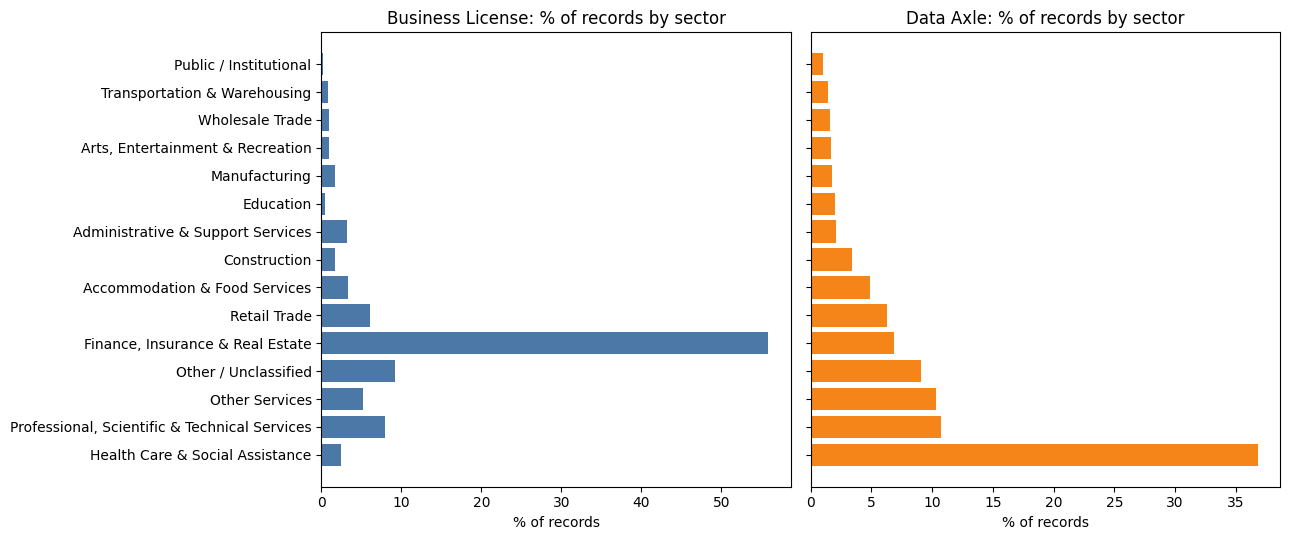

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)
order = sector_comparison.index

axes[0].barh(order, sector_comparison.loc[order, "bl_pct"], color="#4C78A8")
axes[0].set_title("Business License: % of records by sector")
axes[0].invert_yaxis()
axes[0].set_xlabel("% of records")

axes[1].barh(order, sector_comparison.loc[order, "da_pct"], color="#F58518")
axes[1].set_title("Data Axle: % of records by sector")
axes[1].invert_yaxis()
axes[1].set_xlabel("% of records")

plt.tight_layout()
plt.show()

**Takeaway:**

- **Yes — but for the opposite reason you might expect.** DA's Health Care & Social Assistance
  share (~37% of all records) does *not* appear in BL (~2.5%). But BL has its own massive
  concentration: **"Finance, Insurance & Real Estate" is ~56% of all BL records**, almost entirely
  driven by a single NAICS category — *Lessors of Residential Buildings and Dwellings* (i.e.
  **rental-property registrations**, not storefronts). This is a landlord/rental-license
  requirement showing up in the business-license system, not commercial corridor activity.
- This means **neither source's sector mix reflects Oakland's commercial corridors on its own**:
  BL is swamped by residential rental licenses, and DA (as shown in Section 5) is swamped by
  individually-listed health-care practitioners sharing a small number of medical buildings.
- Once we exclude BL's rental-property registrations, its remaining sector mix (Professional
  Services, Retail, Other Services, Food Service) looks much more like a typical commercial base —
  this is a strong candidate filter for any future corridor-focused subset of BL.


## 5. Establishments vs. Physical Locations

Section 2 already hinted that DA has meaningfully more than 1 record per address on average. Here
we look directly at the distribution of records-per-address, in both sources, and ask whether
Health Care specifically drives DA's tail.

This distinction — **number of business entities** vs. **number of unique physical business
locations** — is central to any corridor-density metric: counting raw DA rows would badly
overstate how many *storefronts* occupy a corridor if a hospital or medical tower contributes
hundreds of individually-listed practitioners.

In [19]:
bl_addr_counts = bl_std["address_base"].value_counts()
da_addr_counts = da_std["address_base"].value_counts()

print("Records per unique base address:")
print(pd.DataFrame({
    "BL": bl_addr_counts.describe(),
    "DA": da_addr_counts.describe(),
}).round(2))

Records per unique base address:
             BL        DA
count  33513.00  10599.00
mean       1.39      2.74
std        2.49     14.66
min        1.00      1.00
25%        1.00      1.00
50%        1.00      1.00
75%        1.00      2.00
max      160.00    713.00


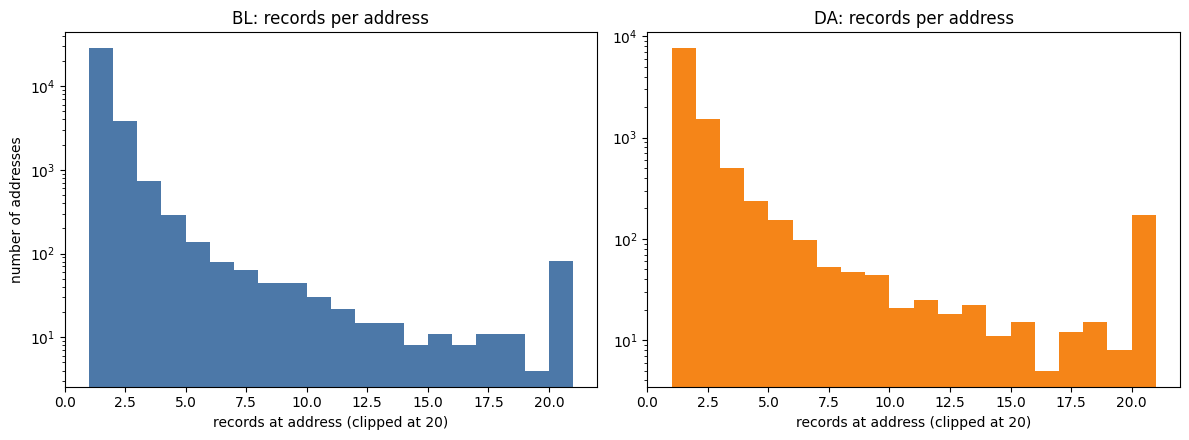

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
max_show = 20

axes[0].hist(bl_addr_counts.clip(upper=max_show), bins=range(1, max_show + 2), color="#4C78A8")
axes[0].set_title("BL: records per address")
axes[0].set_xlabel(f"records at address (clipped at {max_show})")
axes[0].set_ylabel("number of addresses")
axes[0].set_yscale("log")

axes[1].hist(da_addr_counts.clip(upper=max_show), bins=range(1, max_show + 2), color="#F58518")
axes[1].set_title("DA: records per address")
axes[1].set_xlabel(f"records at address (clipped at {max_show})")
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()

In [21]:
print("Top 15 addresses by DA record count:")
top_da_addrs = da_addr_counts.head(15).rename("n_records").to_frame()
top_da_addrs

Top 15 addresses by DA record count:


,n_records
address_base,
1411 E 31ST ST,713
275 W MACARTHUR BLVD,671
747 52ND ST,486
8945 GOLF LINKS RD,406
390 40TH ST,378
3301 E 12TH ST,276
3600 BROADWAY,274
744 52ND ST,202
1266 14TH ST,191


In [22]:
example_addr = da_addr_counts.index[0]
example = da_std.loc[da_std["address_base"] == example_addr,
                     ["Company Name", "Primary NAICS Description", "Home Business"]]
print(f"'{example_addr}' alone accounts for {len(example)} DA records. A sample:")
example.head(15)

'1411 E 31ST ST' alone accounts for 713 DA records. A sample:


,Company Name,Primary NAICS Description,Home Business
410,Aarabi Shahram MD,Offices Of Physicians (Except Mental Health Sp...,No
441,Abdelrahim Marwan MD,Offices Of Physicians (Except Mental Health Sp...,No
484,"Abram, Sharon A",Offices Of Mental Health Practitioners (Except...,No
500,Abulhasan Ahmad DO,Offices Of Physicians (Except Mental Health Sp...,No
595,Acosta Jose Antonio MD,Offices Of Physicians (Except Mental Health Sp...,No
669,Addepalli Aravind MD,Offices Of Physicians (Except Mental Health Sp...,No
685,"Adewole, Virginia A MD",Offices Of Physicians (Except Mental Health Sp...,No
691,"Adkins, Claire MD",Offices Of Physicians (Except Mental Health Sp...,No
695,"Adler, Naomi A MD",Offices Of Physicians (Except Mental Health Sp...,No
717,Adult Immunology Clinic,Offices Of Physicians (Except Mental Health Sp...,No


This top address is a large medical campus, and almost every record there is an individually
listed physician, dentist, or other practitioner — not a separate storefront. This is the
mechanism behind DA's Health Care concentration from Section 4.

In [23]:
da_std["is_health_naics"] = da_std["sector"].eq("Health Care & Social Assistance")
high_count_addrs = da_addr_counts[da_addr_counts >= 5].index
at_high_count_addr = da_std["address_base"].isin(high_count_addrs)

print(f"Addresses with >= 5 DA records: {len(high_count_addrs):,} "
      f"(covering {at_high_count_addr.sum():,} records, {at_high_count_addr.mean()*100:.1f}% of DA)")
print()
print(f"Health Care share among records at high-count addresses: "
      f"{da_std.loc[at_high_count_addr, 'is_health_naics'].mean()*100:.1f}%")
print(f"Health Care share overall (DA):                          "
      f"{da_std['is_health_naics'].mean()*100:.1f}%")

Addresses with >= 5 DA records: 719 (covering 15,916 records, 53.9% of DA)

Health Care share among records at high-count addresses: 59.4%
Health Care share overall (DA):                          36.8%


**Takeaway:**

- DA's health-care records are clearly not evenly spread across the city — they concentrate at a
  small number of medical buildings, each listing many individual practitioners as separate
  "businesses." Addresses with 5+ DA records skew far more toward Health Care than the DA average.
- BL's per-address distribution is much flatter (median 1, long tail thinner) since BL's dominant
  category — rental-property licenses — rarely stacks many records at one address the way a
  hospital stacks physicians.
- **Practical implication:** any corridor metric based on DA should decide up front whether it
  wants *entities* (raw row count) or *locations* (unique address count) — for Health Care in
  particular these two numbers can differ by an order of magnitude at a single address.

## 6. Home-Based vs. Corridor-Facing Businesses

DA includes a `Home Business` flag and a `Location Type` field; BL has neither (no way to tell a
home-based license from a storefront license in this extract). We use what DA offers to test a
simple, transparent relevance classification.

**Caveat up front:** this is a first pass, not a validated typology. It leans on NAICS sector plus
a couple of DA-only flags, and it will misclassify plenty of individual cases (e.g. some health
care and professional-services sectors mix genuinely consumer-facing storefronts with pure office
uses). Treat the category boundaries as provisional.

In [24]:
print("DA 'Home Business' distribution:")
print(da_std["Home Business"].value_counts(dropna=False))
print()
print("DA 'Location Type' distribution:")
print(da_std["Location Type"].value_counts(dropna=False))

DA 'Home Business' distribution:
Home Business
No     26709
Yes     2836
Name: count, dtype: int64

DA 'Location Type' distribution:
Location Type
Single Loc     27361
Branch          2040
Headquarter       78
Subsidiary        66
Name: count, dtype: int64


In [25]:
SECTOR_TO_RELEVANCE = {
    "Retail Trade": "consumer_facing",
    "Accommodation & Food Services": "consumer_facing",
    "Arts, Entertainment & Recreation": "consumer_facing",
    "Health Care & Social Assistance": "consumer_facing",
    "Other Services": "consumer_facing",
    "Education": "institutional",
    "Public / Institutional": "institutional",
    "Professional, Scientific & Technical Services": "office_or_professional",
    "Finance, Insurance & Real Estate": "office_or_professional",
    "Administrative & Support Services": "office_or_professional",
    "Manufacturing": "industrial_logistics",
    "Transportation & Warehousing": "industrial_logistics",
    "Wholesale Trade": "industrial_logistics",
    "Construction": "industrial_logistics",
    "Other / Unclassified": "unknown",
}

def classify_relevance(row):
    if row["Home Business"] == "Yes":
        return "home_based"
    if pd.notna(row["Government Office"]) and str(row["Government Office"]) not in ("0", "nan"):
        return "institutional"
    return SECTOR_TO_RELEVANCE.get(row["sector"], "unknown")

da_std["relevance_class"] = da_std.apply(classify_relevance, axis=1)
relevance_counts = da_std["relevance_class"].value_counts()
relevance_pct = (relevance_counts / len(da_std) * 100).round(1)
pd.DataFrame({"n_records": relevance_counts, "pct": relevance_pct})

,n_records,pct
relevance_class,,
consumer_facing,10906,36.9
institutional,7175,24.3
office_or_professional,4696,15.9
home_based,2836,9.6
industrial_logistics,2004,6.8
unknown,1928,6.5


In [26]:
home = da_std["Home Business"].eq("Yes")
print(f"Home-based share of DA: {home.mean()*100:.1f}% ({home.sum():,} records)")
print()
print("Sector composition of home-based DA records:")
print((da_std.loc[home, "sector"].value_counts(normalize=True) * 100).round(1).head(8))
print()
print("Employee-size-range comparison, home-based vs. not:")
print(pd.crosstab(da_std["Home Business"], da_std["Location Employee Size Range"], normalize="index").round(3) * 100)

Home-based share of DA: 9.6% (2,836 records)

Sector composition of home-based DA records:
sector
Other / Unclassified                             26.5
Professional, Scientific & Technical Services    21.3
Other Services                                   10.8
Health Care & Social Assistance                  10.7
Construction                                     10.5
Finance, Insurance & Real Estate                  5.4
Administrative & Support Services                 4.3
Arts, Entertainment & Recreation                  2.3
Name: proportion, dtype: float64

Employee-size-range comparison, home-based vs. not:
Location Employee Size Range  1 to 4  10 to 19  100 to 249  1000 to 4999  20 to 49  250 to 499  5 to 9  50 to 99  500 to 999
Home Business                                                                                                               
No                              75.8       5.7         0.5           0.1       4.2         0.1    12.2       1.4         0.0
Yes      

**Takeaway:**

- ~10% of DA records are flagged home-based. Their sector mix leans toward Other Services,
  Professional Services, and Health Care/Social Assistance (individual practitioners, consultants,
  personal-service providers) — plausible for home-based work, and a useful mask to remove before
  measuring corridor-facing commercial density.
- Home-based records are overwhelmingly in the smallest employee-size bucket ("1 to 4"), as
  expected.
- The tentative `relevance_class` field gives a rough, sector-plus-flags split into
  `consumer_facing` / `office_or_professional` / `industrial_logistics` / `institutional` /
  `home_based` / `unknown`. It is meant as a **starting point for discussion**, not a finished
  classifier — before relying on it for a real metric it would need validation against a sample of
  actual storefronts, and BL cannot currently be classified the same way since it lacks a
  home-business indicator entirely.

## 7. Cross-Source Address Overlap

Now we test how much BL and DA overlap using simple deterministic address matching, at three
levels of strictness:

1. full normalized address (`address_norm`, includes unit)
2. base street address only (`address_base`, ignoring unit)
3. base street address + ZIP (a light sanity check on top of #2)

We report match rates from **each side's perspective separately** — matched-DA-% and matched-BL-%
are not the same number, since the two files are very different sizes and compositions.

In [27]:
bl_norm_set = set(bl_std["address_norm"].dropna())
bl_base_set = set(bl_std["address_base"].dropna())
da_norm_set = set(da_std["address_norm"].dropna())
da_base_set = set(da_std["address_base"].dropna())

da_std["matched_full_addr"] = da_std["address_norm"].notna() & da_std["address_norm"].isin(bl_norm_set)
da_std["matched_base_addr"] = da_std["address_base"].notna() & da_std["address_base"].isin(bl_base_set)
bl_std["matched_full_addr"] = bl_std["address_norm"].notna() & bl_std["address_norm"].isin(da_norm_set)
bl_std["matched_base_addr"] = bl_std["address_base"].notna() & bl_std["address_base"].isin(da_base_set)

# base address + zip5 (both must agree)
da_base_zip_set = set(zip(da_std["address_base"], da_std["zip5"]))
bl_base_zip_set = set(zip(bl_std["address_base"], bl_std["zip5"]))
da_std["matched_base_addr_zip"] = da_std.apply(
    lambda r: pd.notna(r["address_base"]) and (r["address_base"], r["zip5"]) in bl_base_zip_set, axis=1
)
bl_std["matched_base_addr_zip"] = bl_std.apply(
    lambda r: pd.notna(r["address_base"]) and (r["address_base"], r["zip5"]) in da_base_zip_set, axis=1
)

match_summary = pd.DataFrame({
    "match_level": ["full normalized address", "base street address", "base address + ZIP"],
    "da_matched_n": [da_std["matched_full_addr"].sum(), da_std["matched_base_addr"].sum(), da_std["matched_base_addr_zip"].sum()],
    "da_matched_pct": [round(da_std[c].mean()*100, 1) for c in ["matched_full_addr", "matched_base_addr", "matched_base_addr_zip"]],
    "bl_matched_n": [bl_std["matched_full_addr"].sum(), bl_std["matched_base_addr"].sum(), bl_std["matched_base_addr_zip"].sum()],
    "bl_matched_pct": [round(bl_std[c].mean()*100, 1) for c in ["matched_full_addr", "matched_base_addr", "matched_base_addr_zip"]],
})
match_summary

,match_level,da_matched_n,da_matched_pct,bl_matched_n,bl_matched_pct
0,full normalized address,14318,48.5,8663,18.6
1,base street address,22903,77.5,15552,33.4
2,base address + ZIP,22869,77.4,15537,33.4


**Takeaway:** roughly **half of DA records match a BL address exactly (unit included)**, rising to
**~78% on base-street-address alone** — most of the gap between those two numbers is just
unit/suite formatting differences, not genuinely different locations. From BL's side, only
**~19–25% of records find any DA match**, which is expected: BL is roughly 1.6x the size of DA and
dominated by rental-property registrations that DA (a commercial database) never listed to begin
with.

### Match cardinality (one-to-one vs. one-to-many vs. many-to-many)

A shared base address does not necessarily mean a clean 1:1 correspondence — a single building can
hold multiple BL licenses and multiple DA listings simultaneously. We classify every shared
`address_base` key by how many records each side contributes.

In [28]:
bl_key_counts = bl_std["address_base"].value_counts()
da_key_counts = da_std["address_base"].value_counts()
common_keys = set(bl_key_counts.index) & set(da_key_counts.index)

def classify_cardinality(k):
    b, d = bl_key_counts[k], da_key_counts[k]
    if b == 1 and d == 1:
        return "one-to-one"
    if d == 1 and b > 1:
        return "many(BL)-to-one(DA)"
    if b == 1 and d > 1:
        return "one(BL)-to-many(DA)"
    return "many-to-many"

cardinality = pd.Series([classify_cardinality(k) for k in common_keys]).value_counts()
cardinality_pct = (cardinality / cardinality.sum() * 100).round(1)
print(f"Shared base-address keys between BL and DA: {len(common_keys):,}")
pd.DataFrame({"n_addresses": cardinality, "pct": cardinality_pct})

Shared base-address keys between BL and DA: 6,244


,n_addresses,pct
one-to-one,2595,41.6
many-to-many,1434,23.0
many(BL)-to-one(DA),1368,21.9
one(BL)-to-many(DA),847,13.6


**Takeaway:** only about 4 in 10 shared addresses are a clean one-to-one match; the rest involve
multiple BL licenses, multiple DA listings, or both at the same address. This confirms that address
matching alone will need a tie-breaking signal (business name, once available, or NAICS
compatibility) for a meaningful share of matches — pure address equality is necessary but not
sufficient for entity resolution.

### Do matched records agree on broad sector?

Where both sides have NAICS information, we check broad-sector agreement among matched
(base-address) pairs — allowing for one-to-many matches by comparing each DA record's sector
against the *set* of sectors present at that BL address.

In [29]:
bl_sector_by_addr = bl_std.dropna(subset=["address_base"]).groupby("address_base")["sector"].apply(set)

matched_da = da_std[da_std["matched_base_addr"]].copy()
matched_da["bl_sectors_at_addr"] = matched_da["address_base"].map(bl_sector_by_addr)
matched_da["sector_compatible"] = matched_da.apply(
    lambda r: isinstance(r["bl_sectors_at_addr"], set) and r["sector"] in r["bl_sectors_at_addr"], axis=1
)

print(f"Among {len(matched_da):,} address-matched DA records, "
      f"{matched_da['sector_compatible'].mean()*100:.1f}% share a broad sector with at least one "
      f"BL record at the same address.")

Among 22,903 address-matched DA records, 54.8% share a broad sector with at least one BL record at the same address.


**Takeaway:** sector agreement among address-matched records is moderate rather than high — not
surprising given how many BL records at a shared address are unrelated rental-property listings
with a completely different (real estate) sector code than the DA business actually operating
there. This is a useful diagnostic, not a matching filter: **detailed NAICS disagreement is
expected and should not by itself disqualify a match**, per the original brief.

## 8. Spatial Proximity Matching

Address matching depends on both sources spelling/formatting addresses the same way. Coordinates
offer an independent signal. We project both datasets to a local projected CRS
(`EPSG:26910`, NAD83 UTM zone 10N — meters) and, for every DA point, find the nearest BL point via
a vectorized GeoPandas nearest-neighbor join (no row-by-row Python loop needed).

In [30]:
bl_geo = bl_std.dropna(subset=["lat_std", "lon_std"]).copy()
da_geo = da_std.dropna(subset=["lat_std", "lon_std"]).copy()

bl_gdf = gpd.GeoDataFrame(
    bl_geo, geometry=gpd.points_from_xy(bl_geo["lon_std"], bl_geo["lat_std"]), crs="EPSG:4326"
).to_crs(LOCAL_CRS)
da_gdf = gpd.GeoDataFrame(
    da_geo, geometry=gpd.points_from_xy(da_geo["lon_std"], da_geo["lat_std"]), crs="EPSG:4326"
).to_crs(LOCAL_CRS)

print(f"BL points: {len(bl_gdf):,}   DA points: {len(da_gdf):,}")

BL points: 45,939   DA points: 29,545


In [31]:
nearest = gpd.sjoin_nearest(da_gdf, bl_gdf[["geometry"]], distance_col="dist_m", how="left")
# sjoin_nearest returns every tied nearest match (common when several BL records share one
# geocode); keep just the first tie per DA record so distances aren't double-counted.
nearest = nearest[~nearest.index.duplicated(keep="first")]

da_gdf["nearest_bl_dist_m"] = nearest["dist_m"]
print(da_gdf["nearest_bl_dist_m"].describe().round(1))

count     29545.0
mean         61.2
std        3237.4
min           0.1
25%          17.7
50%          29.0
75%          52.2
max      556294.6
Name: nearest_bl_dist_m, dtype: float64


In [32]:
for thresh in DISTANCE_THRESHOLDS_M:
    pct = (da_gdf["nearest_bl_dist_m"] <= thresh).mean() * 100
    print(f"DA records with a BL point within {thresh:>3d}m: {pct:5.1f}%")

DA records with a BL point within  10m:  12.1%
DA records with a BL point within  25m:  43.8%
DA records with a BL point within  50m:  72.9%
DA records with a BL point within 100m:  92.1%


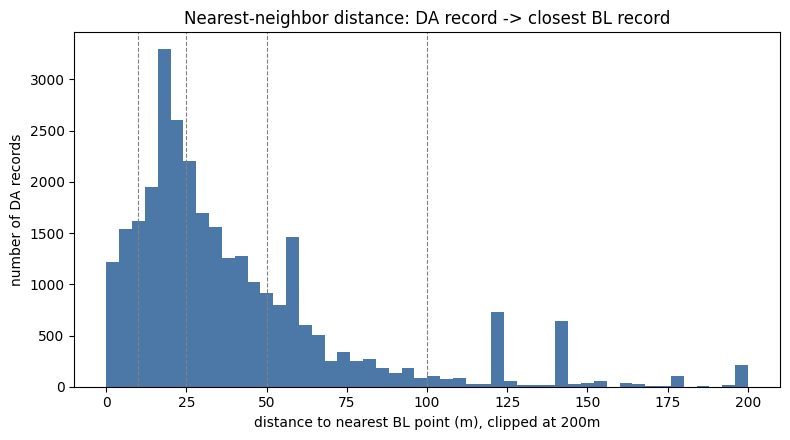

In [33]:
fig, ax = plt.subplots(figsize=(8, 4.5))
plot_dist = da_gdf["nearest_bl_dist_m"].clip(upper=200)
ax.hist(plot_dist, bins=50, color="#4C78A8")
for thresh in DISTANCE_THRESHOLDS_M:
    ax.axvline(thresh, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("distance to nearest BL point (m), clipped at 200m")
ax.set_ylabel("number of DA records")
ax.set_title("Nearest-neighbor distance: DA record -> closest BL record")
plt.tight_layout()
plt.show()

**Takeaway:** nearest-neighbor distance is heavily concentrated under ~50m — consistent with most
DA and BL records reflecting the same underlying parcel/geocoding source even when their address
strings don't match textually. Coordinates clearly carry standalone matching signal.

### Combining address agreement and spatial proximity

Finally we cross-tabulate exact base-address matching against a simple spatial-proximity cutoff
(here, 50m) to see how much each method adds beyond the other.

In [34]:
SPATIAL_MATCH_THRESHOLD_M = 50
da_gdf["spatially_close"] = da_gdf["nearest_bl_dist_m"] <= SPATIAL_MATCH_THRESHOLD_M
da_gdf["addr_match"] = da_gdf["matched_base_addr"].values

def combo_label(row):
    if row["addr_match"] and row["spatially_close"]:
        return "address match + spatially close"
    if not row["addr_match"] and row["spatially_close"]:
        return "no address match, but spatially close"
    if row["addr_match"] and not row["spatially_close"]:
        return "address match, but coordinates far apart"
    return "unmatched by either method"

combo_counts = da_gdf.apply(combo_label, axis=1).value_counts()
combo_pct = (combo_counts / combo_counts.sum() * 100).round(1)
pd.DataFrame({"n_records": combo_counts, "pct": combo_pct})

,n_records,pct
address match + spatially close,16345,55.3
"address match, but coordinates far apart",6558,22.2
"no address match, but spatially close",5187,17.6
unmatched by either method,1455,4.9


**Takeaway:** just over half of DA records (55%) land in the clean "address match +
spatially close" bucket. The next-largest group, though, is **"address match, but coordinates far
apart" (22%)** - larger than the "no address match, but spatially close" group (18%). That is a
useful, slightly counterintuitive finding: textual address agreement does not guarantee coordinate
agreement, so this bucket is worth a manual look for geocoding errors in one source or the other
before trusting either coordinate blindly. The 18% "no address match, but spatially close" group is
exactly where coordinate proximity adds value that address matching alone misses (formatting
differences, different unit numbers, minor spelling variation). Only 5% of DA records are unmatched
by both methods. Practical conclusion: **spatial proximity is a genuinely useful supplementary
signal**, not a replacement for address matching - and the two methods disagree often enough that
neither should be trusted alone.


## 9. Lightweight Fuzzy Matching Experiment

This is a small, exploratory test of fuzzy address matching among records that exact matching
(Section 7) could not resolve — **not** a production entity-resolution pass. We block candidates by
ZIP code (so we never compare every business against every other business), then score
candidate pairs with RapidFuzz.

In [35]:
print("RapidFuzz available:", HAS_RAPIDFUZZ)

RapidFuzz available: True


In [36]:
da_unmatched = da_std[~da_std["matched_base_addr"] & da_std["address_base"].notna() & da_std["zip5"].notna()].copy()
bl_unmatched = bl_std[~bl_std["matched_base_addr"] & bl_std["address_base"].notna() & bl_std["zip5"].notna()].copy()
print(f"Unmatched DA records available for fuzzy test: {len(da_unmatched):,}")
print(f"Unmatched BL records available for fuzzy test: {len(bl_unmatched):,}")

bl_blocks = {zip5: grp["address_base"].tolist() for zip5, grp in bl_unmatched.groupby("zip5")}

Unmatched DA records available for fuzzy test: 6,134
Unmatched BL records available for fuzzy test: 30,962


In [37]:
SAMPLE_N = 1500
FUZZY_SCORE_CUTOFF = 80

da_sample = da_unmatched.sample(min(SAMPLE_N, len(da_unmatched)), random_state=RNG_SEED)

fuzzy_results = []
if HAS_RAPIDFUZZ:
    for idx, row in tqdm(da_sample.iterrows(), total=len(da_sample), desc="fuzzy matching (blocked by ZIP)"):
        candidates = bl_blocks.get(row["zip5"])
        if not candidates:
            continue
        best = process.extractOne(row["address_base"], candidates, scorer=fuzz.token_sort_ratio,
                                   score_cutoff=FUZZY_SCORE_CUTOFF)
        if best is not None:
            match_str, score, _ = best
            fuzzy_results.append({
                "da_address": row["address_base"], "bl_address": match_str, "score": score,
                "da_company": row["Company Name"],
            })

fuzzy_df = pd.DataFrame(fuzzy_results)
print(f"Fuzzy candidate matches found (score >= {FUZZY_SCORE_CUTOFF}): {len(fuzzy_df):,} "
      f"out of {len(da_sample):,} sampled unmatched DA records")

fuzzy matching (blocked by ZIP):   0%|          | 0/1500 [00:00<?, ?it/s]

Fuzzy candidate matches found (score >= 80): 1,263 out of 1,500 sampled unmatched DA records


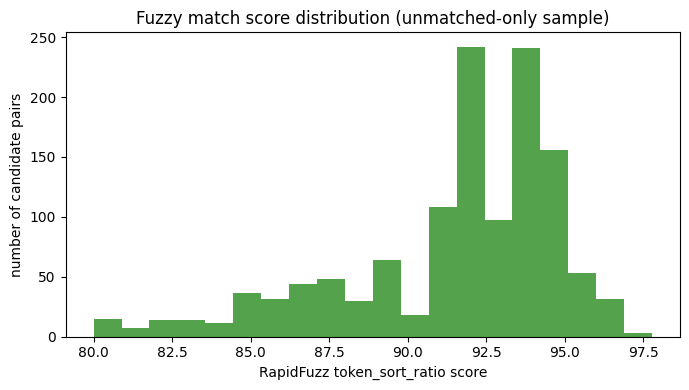

In [38]:
if len(fuzzy_df):
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(fuzzy_df["score"], bins=20, color="#54A24B")
    ax.set_xlabel("RapidFuzz token_sort_ratio score")
    ax.set_ylabel("number of candidate pairs")
    ax.set_title("Fuzzy match score distribution (unmatched-only sample)")
    plt.tight_layout()
    plt.show()

In [39]:
if len(fuzzy_df):
    print("High-confidence examples (score >= 95):")
    display_cols = ["da_address", "bl_address", "score"]
    print(fuzzy_df[fuzzy_df["score"] >= 95][display_cols].drop_duplicates().head(8).to_string(index=False))
    print()
    print("Ambiguous examples (80 <= score < 88):")
    print(fuzzy_df[fuzzy_df["score"].between(80, 88)][display_cols].drop_duplicates().head(8).to_string(index=False))

High-confidence examples (score >= 95):
                    da_address                     bl_address     score
        825 INTERNATIONAL BLVD         725 INTERNATIONAL BLVD 95.454545
5638 MARTIN LUTHER KING JR WAY 5628 MARTIN LUTHER KING JR WAY 96.666667
                  110 BROADWAY                  1120 BROADWAY 96.000000
       1353 INTERNATIONAL BLVD        1633 INTERNATIONAL BLVD 95.652174
       8102 INTERNATIONAL BLVD        8610 INTERNATIONAL BLVD 95.652174
3412 MARTIN LUTHER KING JR WAY 3120 MARTIN LUTHER KING JR WAY 96.666667
          3845 FOREST HILL AVE           3824 FOREST HILL AVE 95.000000
       1721 INTERNATIONAL BLVD        1241 INTERNATIONAL BLVD 95.652174

Ambiguous examples (80 <= score < 88):
      da_address       bl_address     score
   8401 BIRCH ST    8600 BIRCH ST 84.615385
   5525 ASCOT DR    6532 ASCOT DR 84.615385
2999 GLASCOCK ST 2943 GLASCOCK ST 87.500000
5600 COLLEGE AVE 5403 COLLEGE AVE 87.500000
 1523 WEBSTER ST  1218 WEBSTER ST 86.666667
5812 COL

**Takeaway - and a genuine caution, not just a summary:** looking at the actual score>=95
examples above, several are **not** true matches at all - `825 INTERNATIONAL BLVD` vs.
`725 INTERNATIONAL BLVD`, `110 BROADWAY` vs. `1120 BROADWAY`, `3412 MARTIN LUTHER KING JR WAY` vs.
`3120 MARTIN LUTHER KING JR WAY` are different house numbers, almost certainly different buildings,
that still score >=95 on `token_sort_ratio` because the (long, identical) street-name tokens
dominate the string and swamp a one- or two-digit difference in the house number. This is a real
weakness of plain string-similarity scoring for addresses, not a labeling error in this notebook -
and it is exactly why the brief warns against merging on fuzzy score alone. The 80-88 "ambiguous"
band has the same failure mode even more visibly (`8401 BIRCH ST` vs. `8600 BIRCH ST`,
`5525 ASCOT DR` vs. `6532 ASCOT DR`): same street, different block, clearly different addresses.

**Practical conclusion:** a fuzzy address score by itself cannot reliably distinguish "same
building, minor formatting difference" from "different building, same street" - it needs to be
combined with independent evidence (coordinate proximity from Section 8, eventually business name)
before a match is trusted, confirming the hierarchy below.

**A sketch of an eventual matching hierarchy**, from most to least reliable:

1. exact normalized address (Section 7)
2. spatial proximity + a compatible (if imperfect) address (Section 8)
3. fuzzy address match *and* nearby coordinates - given the false-positive pattern just shown,
   fuzzy score alone should never be sufficient on its own
4. additional business-name evidence, once a comparable name field exists on the BL side (it does
   not today - see Section 1) and once D&B is available
5. manual review for anything left ambiguous

No records are auto-merged in this notebook on the strength of a fuzzy score alone - that decision
belongs in the eventual entity-resolution step, with more evidence (ideally including a business
name on both sides, and coordinate agreement) than a bare address-string score provides.


## 10. Source Disagreement by Sector

Section 4 already showed the headline gap (BL's rental-property share vs. DA's Health Care share).
Here we quantify sector disagreement more systematically, and repeat the comparison at the level
of **unique physical addresses** rather than raw entity counts, since Section 5 showed those can
tell different stories.

In [40]:
def sector_share_table(bl_series, da_series, label):
    bl_counts = bl_series.value_counts()
    da_counts = da_series.value_counts()
    tbl = pd.DataFrame({"bl_count": bl_counts, "da_count": da_counts}).fillna(0)
    tbl["bl_share_pct"] = (tbl["bl_count"] / tbl["bl_count"].sum() * 100).round(1)
    tbl["da_share_pct"] = (tbl["da_count"] / tbl["da_count"].sum() * 100).round(1)
    tbl["pct_point_diff (DA - BL)"] = (tbl["da_share_pct"] - tbl["bl_share_pct"]).round(1)
    tbl = tbl.sort_values("pct_point_diff (DA - BL)", ascending=False)
    print(f"--- {label} ---")
    return tbl

sector_by_entity = sector_share_table(bl_std["sector"], da_std["sector"], "all business entities")
sector_by_entity

--- all business entities ---


,bl_count,da_count,bl_share_pct,da_share_pct,pct_point_diff (DA - BL)
sector,,,,,
Health Care & Social Assistance,1163,10866,2.5,36.8,34.3
Other Services,2411,3054,5.2,10.3,5.1
"Professional, Scientific & Technical Services",3680,3159,7.9,10.7,2.8
Construction,777,1010,1.7,3.4,1.7
Accommodation & Food Services,1553,1456,3.3,4.9,1.6
Education,209,599,0.4,2.0,1.6
"Arts, Entertainment & Recreation",416,492,0.9,1.7,0.8
Public / Institutional,94,304,0.2,1.0,0.8
Wholesale Trade,433,459,0.9,1.6,0.7


In [41]:
bl_one_sector_per_addr = bl_std.dropna(subset=["address_base"]).drop_duplicates("address_base")["sector"]
da_one_sector_per_addr = da_std.dropna(subset=["address_base"]).drop_duplicates("address_base")["sector"]
sector_by_location = sector_share_table(bl_one_sector_per_addr, da_one_sector_per_addr,
                                         "unique physical addresses (first record per address)")
sector_by_location

--- unique physical addresses (first record per address) ---


,bl_count,da_count,bl_share_pct,da_share_pct,pct_point_diff (DA - BL)
sector,,,,,
Other Services,1373,1822,4.1,17.2,13.1
Health Care & Social Assistance,513,1088,1.5,10.3,8.8
Other / Unclassified,2527,1397,7.5,13.2,5.7
Accommodation & Food Services,973,858,2.9,8.1,5.2
Retail Trade,1606,1042,4.8,9.8,5.0
"Professional, Scientific & Technical Services",2060,1156,6.1,10.9,4.8
Construction,509,601,1.5,5.7,4.2
Education,127,275,0.4,2.6,2.2
"Arts, Entertainment & Recreation",240,281,0.7,2.7,2.0


In [42]:
da_non_home = da_std.loc[~da_std["Home Business"].eq("Yes")]
sector_excl_home = sector_share_table(bl_std["sector"], da_non_home["sector"],
                                       "all entities, DA home-businesses excluded")
sector_excl_home

--- all entities, DA home-businesses excluded ---


,bl_count,da_count,bl_share_pct,da_share_pct,pct_point_diff (DA - BL)
sector,,,,,
Health Care & Social Assistance,1163,10563,2.5,39.5,37.0
Other Services,2411,2747,5.2,10.3,5.1
Accommodation & Food Services,1553,1440,3.3,5.4,2.1
"Professional, Scientific & Technical Services",3680,2556,7.9,9.6,1.7
Education,209,537,0.4,2.0,1.6
Construction,777,712,1.7,2.7,1.0
Public / Institutional,94,304,0.2,1.1,0.9
Wholesale Trade,433,427,0.9,1.6,0.7
Retail Trade,2854,1805,6.1,6.8,0.7


**Takeaway:** the two largest discrepancies by far are **Finance/Insurance/Real Estate**
(BL >> DA, driven by rental-property licenses) and **Health Care & Social Assistance**
(DA >> BL, driven by individually-listed practitioners). Collapsing to one record per address
narrows — but does not close — the health care gap, confirming that shared addresses explain
part, not all, of DA's health care concentration (a real, if smaller, excess of distinct health
care *locations* remains). Excluding DA home-businesses barely moves the picture, since home-based
records are a small share of DA overall (Section 6). The clear implication for the combined
database: **each source's sector composition should be treated as a source-specific bias to
correct for, not descriptive of Oakland's actual commercial mix.**

## 11. Spatial Distribution and Commercial Intensity

We compare the spatial footprint of BL records, all DA records, unique DA physical locations, and
DA records classified `consumer_facing` (Section 6). To keep the maps legible at this record
count we use small semi-transparent points rather than opaque markers, and share the same map
extent across panels for a fair visual comparison.

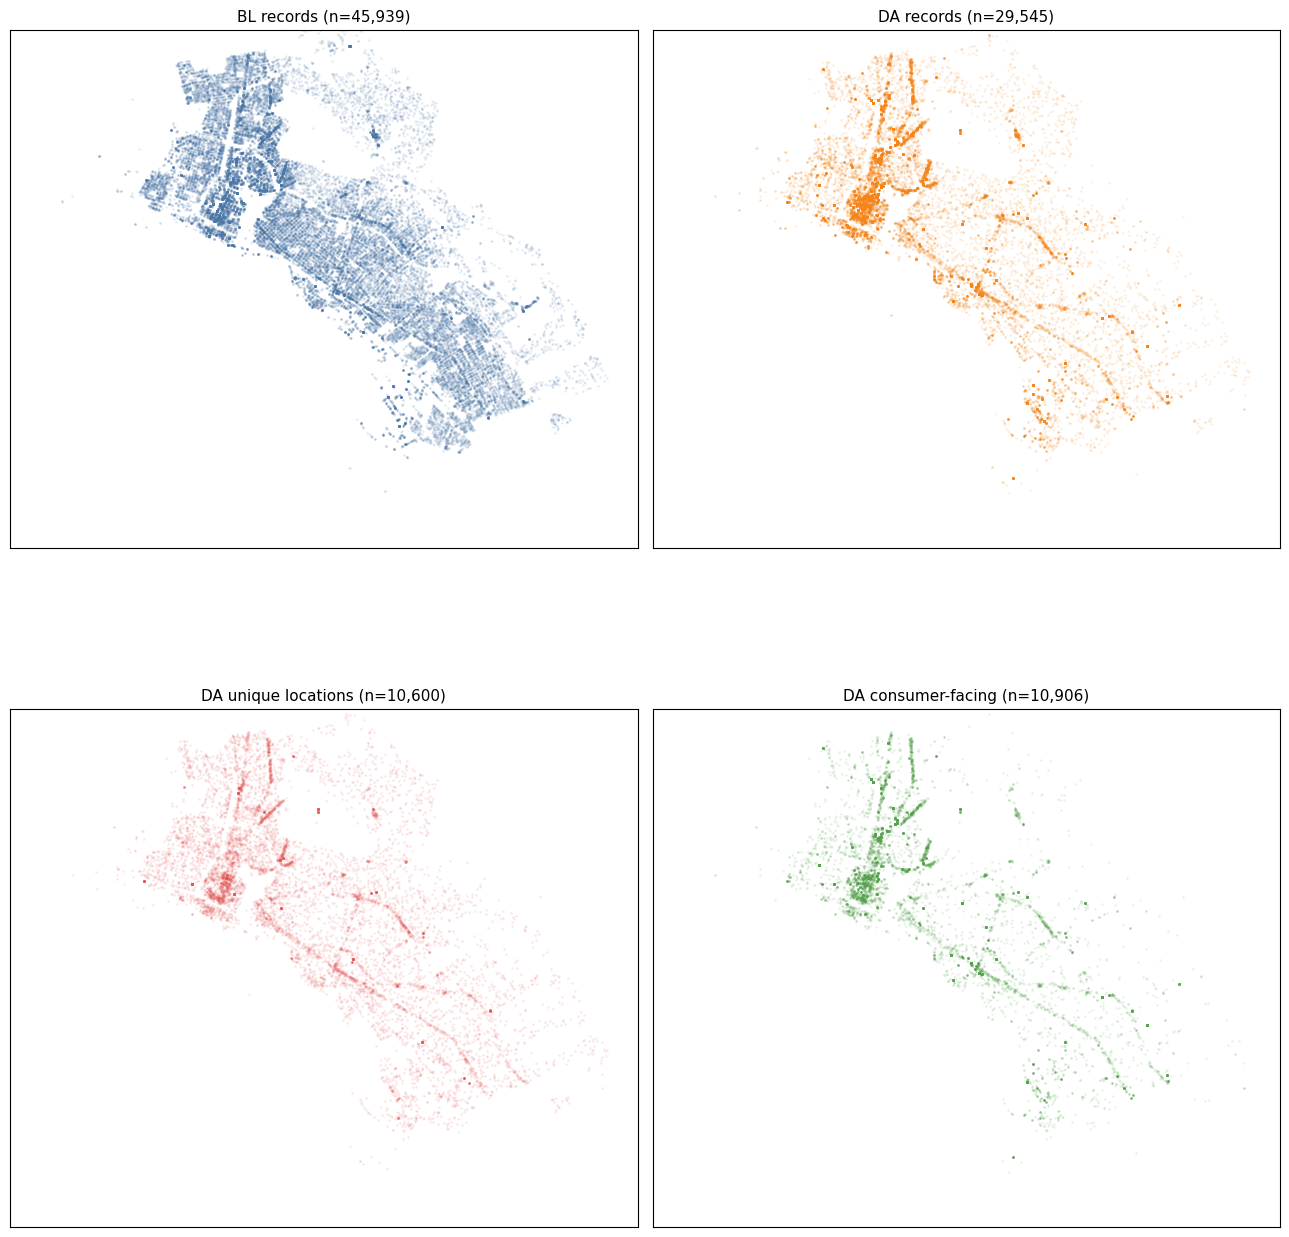

In [43]:
MAP_XLIM = (-122.355, -122.105)
MAP_YLIM = (37.695, 37.86)

def scatter_panel(ax, lon, lat, title, color):
    ax.scatter(lon, lat, s=3, alpha=0.15, color=color, linewidths=0)
    ax.set_xlim(*MAP_XLIM)
    ax.set_ylim(*MAP_YLIM)
    ax.set_aspect(1.25)
    ax.set_title(title, fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])

da_unique_loc = da_std.dropna(subset=["lat_std", "lon_std"]).drop_duplicates("address_base")
da_consumer = da_std[da_std["relevance_class"].eq("consumer_facing")].dropna(subset=["lat_std", "lon_std"])

fig, axes = plt.subplots(2, 2, figsize=(13, 15))
axes = axes.ravel()
scatter_panel(axes[0], bl_std["lon_std"], bl_std["lat_std"], f"BL records (n={bl_std['lon_std'].notna().sum():,})", "#4C78A8")
scatter_panel(axes[1], da_std["lon_std"], da_std["lat_std"], f"DA records (n={da_std['lon_std'].notna().sum():,})", "#F58518")
scatter_panel(axes[2], da_unique_loc["lon_std"], da_unique_loc["lat_std"], f"DA unique locations (n={len(da_unique_loc):,})", "#E45756")
scatter_panel(axes[3], da_consumer["lon_std"], da_consumer["lat_std"], f"DA consumer-facing (n={len(da_consumer):,})", "#54A24B")
plt.tight_layout()
plt.show()


**Takeaway:** the raw BL and DA point clouds look broadly similar at the city scale — both trace
Oakland's commercial corridors along International Blvd, Telegraph/Broadway, MacArthur Blvd, and
the Downtown/Jack London/Chinatown core. Collapsing DA down to unique locations visibly thins out
a handful of dense clusters (the medical buildings from Section 5) without changing the overall
shape. The consumer-facing subset is noticeably more corridor-concentrated — it thins out office
parks and industrial areas more than it thins out traditional retail streets, which is a
reasonable sanity check on the Section 6 classification. **Different definitions of "business" do
shift the apparent geography somewhat, but the broad commercial corridors are recognizable under
every definition.**

## 12. Compare Against Existing Corridor Polygons

We load the two existing corridor/policy shapefiles and check what share of each business dataset
falls inside a Business Improvement District (BID), a Policy Polygon, either, or neither. As
stated up front, these polygons are a known-incomplete picture of Oakland commercial activity —
the interesting number here is **how much activity currently sits outside them**, not whether
businesses "belong."

In [44]:
bids = gpd.read_file(BID_PATH)[["BID", "geometry"]]
policy_polygons = gpd.read_file(PP_PATH)[["PP_Name", "geometry"]]
print("BIDs:", bids.crs, "-", bids["BID"].tolist())
print("Policy polygons:", policy_polygons.crs, "-", policy_polygons["PP_Name"].tolist())

BIDs: EPSG:4269 - ['Downtown', 'Chinatown', 'Lake Merritt', 'Koreatown/Northgate', 'Montclair', 'Rockridge', 'Temescal/Telegraph', 'Fruitvale', 'Lakeshore', 'Jack London', 'Laurel']
Policy polygons: EPSG:4269 - ['Seventh Thrives', 'West Oakland S', 'Little Saigon', 'Hegenberger_BID', 'Beat19x', 'Fruitvale_BID', 'Telegraph Triangle', 'Old_Oakland', 'Dimond']


In [45]:
def flag_within(gdf, polygons, poly_col):
    """Boolean, one entry per row of gdf: does this point fall within any polygon?"""
    polygons_ll = polygons.to_crs(gdf.crs)
    joined = gpd.sjoin(gdf, polygons_ll, how="left", predicate="within")
    joined = joined[~joined.index.duplicated(keep="first")]   # a point can't be double-counted for overlapping polygons
    return joined[poly_col].notna().reindex(gdf.index).fillna(False)

def corridor_overlay_summary(gdf, label):
    in_bid = flag_within(gdf, bids, "BID").astype(bool)
    in_pp = flag_within(gdf, policy_polygons, "PP_Name").astype(bool)
    in_either = in_bid | in_pp
    n = len(gdf)
    return {
        "dataset": label, "n_records": n,
        "pct_in_BID": round(in_bid.mean() * 100, 1),
        "pct_in_policy_polygon": round(in_pp.mean() * 100, 1),
        "pct_in_either": round(in_either.mean() * 100, 1),
        "pct_outside_both": round((~in_either).mean() * 100, 1),
    }

bl_pts = gpd.GeoDataFrame(bl_std.dropna(subset=["lat_std","lon_std"]),
                           geometry=gpd.points_from_xy(bl_std.dropna(subset=["lat_std","lon_std"])["lon_std"],
                                                        bl_std.dropna(subset=["lat_std","lon_std"])["lat_std"]),
                           crs="EPSG:4326")
da_pts = gpd.GeoDataFrame(da_std.dropna(subset=["lat_std","lon_std"]),
                           geometry=gpd.points_from_xy(da_std.dropna(subset=["lat_std","lon_std"])["lon_std"],
                                                        da_std.dropna(subset=["lat_std","lon_std"])["lat_std"]),
                           crs="EPSG:4326")
da_consumer_pts = da_pts[da_pts["relevance_class"].eq("consumer_facing")]

overlay_summary = pd.DataFrame([
    corridor_overlay_summary(bl_pts, "Business License"),
    corridor_overlay_summary(da_pts, "Data Axle (all)"),
    corridor_overlay_summary(da_consumer_pts, "Data Axle (consumer-facing)"),
]).set_index("dataset")
overlay_summary

,n_records,pct_in_BID,pct_in_policy_polygon,pct_in_either,pct_outside_both
dataset,,,,,
Business License,45939,13.6,10.0,21.0,79.0
Data Axle (all),29545,35.2,17.9,44.8,55.2
Data Axle (consumer-facing),10906,37.4,18.7,47.7,52.3


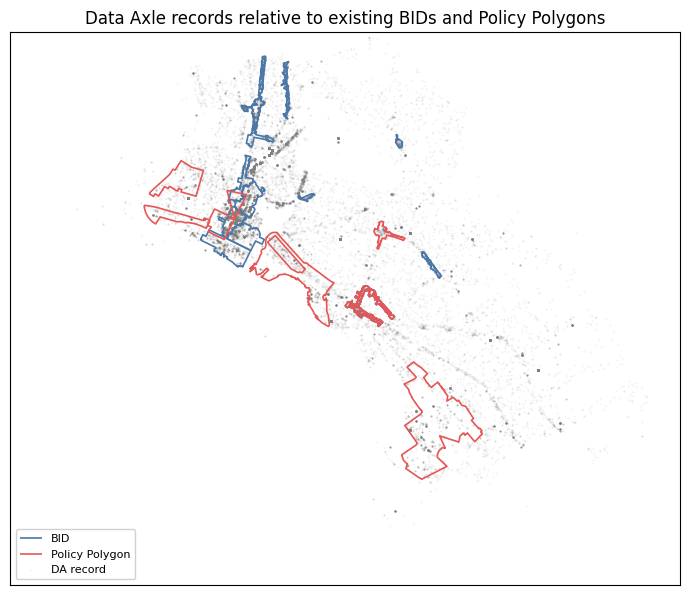

In [46]:
fig, ax = plt.subplots(figsize=(7, 8))
bids.to_crs("EPSG:4326").boundary.plot(ax=ax, color="#4C78A8", linewidth=1.2, label="BID")
policy_polygons.to_crs("EPSG:4326").boundary.plot(ax=ax, color="#E45756", linewidth=1.2, label="Policy Polygon")
ax.scatter(da_pts["lon_std"], da_pts["lat_std"], s=2, alpha=0.1, color="gray", linewidths=0, label="DA record")
ax.set_xlim(*MAP_XLIM); ax.set_ylim(*MAP_YLIM)
ax.set_aspect(1.25)
ax.set_xticks([]); ax.set_yticks([])
ax.set_title("Data Axle records relative to existing BIDs and Policy Polygons")
ax.legend(loc="lower left", fontsize=8, framealpha=0.9)
plt.tight_layout()
plt.show()

**Takeaway:** the majority of business records fall **outside both existing BID and Policy
Polygon boundaries** - about **79% of BL records**, **55% of all DA records**, and **52% of
consumer-facing DA records**. BL's higher outside-both share is expected, since it includes
citywide rental-property licenses with no reason to sit in a commercial corridor. Even for DA's
consumer-facing subset, though, roughly half of records sit outside both polygon types, and the
map shows clear point clusters *outside* the mapped polygons along stretches of several major
arterials - consistent with the brief's premise that the existing corridor shapefiles are an
incomplete picture of Oakland's actual commercial geography. This gap is exactly the motivation
for the density exploration in Section 13.


## 13. Preliminary Business-Density Exploration

As a step toward eventual corridor design (not attempted here), we look at business intensity
independent of the existing polygons, using simple hexbin aggregation. We keep the same extent and
bin size across panels so the three surfaces are visually comparable.

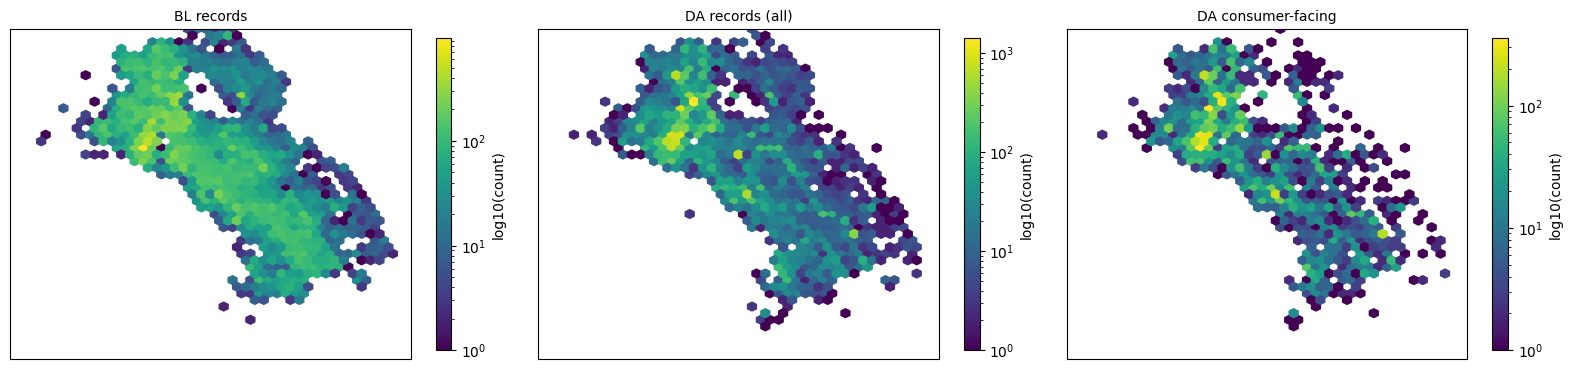

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
panels = [
    (bl_std["lon_std"], bl_std["lat_std"], "BL records"),
    (da_std["lon_std"], da_std["lat_std"], "DA records (all)"),
    (da_consumer["lon_std"], da_consumer["lat_std"], "DA consumer-facing"),
]
for ax, (lon, lat, title) in zip(axes, panels):
    hb = ax.hexbin(lon.dropna(), lat.dropna(), gridsize=45, extent=(*MAP_XLIM, *MAP_YLIM),
                    cmap="viridis", mincnt=1, bins="log")
    ax.set_xlim(*MAP_XLIM); ax.set_ylim(*MAP_YLIM)
    ax.set_aspect(1.25)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title, fontsize=10)
    fig.colorbar(hb, ax=ax, shrink=0.6, label="log10(count)")
plt.tight_layout()
plt.show()

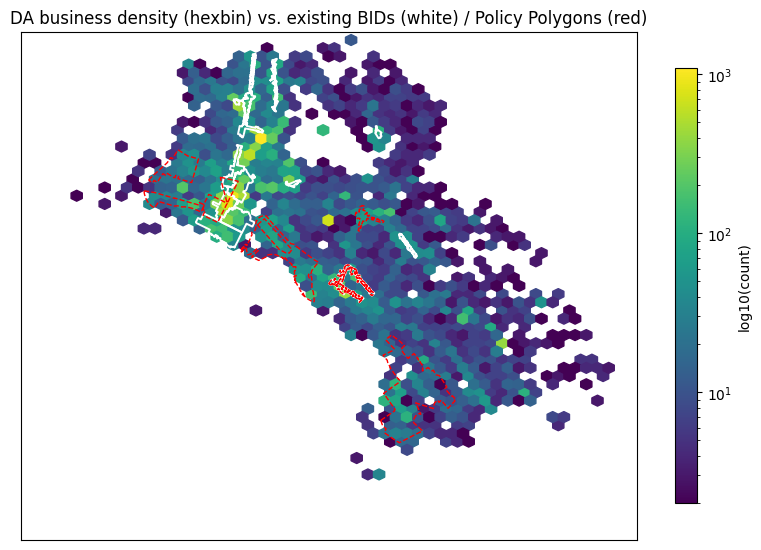

In [48]:
bids_ll = bids.to_crs("EPSG:4326")
policy_polygons_ll = policy_polygons.to_crs("EPSG:4326")

fig, ax = plt.subplots(figsize=(8, 9))
hb = ax.hexbin(da_std["lon_std"].dropna(), da_std["lat_std"].dropna(), gridsize=55,
               extent=(*MAP_XLIM, *MAP_YLIM), cmap="viridis", mincnt=2, bins="log")
bids_ll.boundary.plot(ax=ax, color="white", linewidth=1.4)
policy_polygons_ll.boundary.plot(ax=ax, color="red", linewidth=1.0, linestyle="--")
ax.set_xlim(*MAP_XLIM); ax.set_ylim(*MAP_YLIM)
ax.set_aspect(1.25)
ax.set_xticks([]); ax.set_yticks([])
ax.set_title("DA business density (hexbin) vs. existing BIDs (white) / Policy Polygons (red)")
fig.colorbar(hb, ax=ax, shrink=0.5, label="log10(count)")
plt.tight_layout()
plt.show()

**Takeaway:** density surfaces highlight a few corridor segments with clear business concentration
that fall entirely outside the current polygon set — most visibly along parts of International
Blvd/East 14th deeper into East Oakland, and stretches of MacArthur Blvd and Foothill Blvd, beyond
where the mapped BIDs/Policy Polygons currently end. This is consistent with Section 12's finding
that a majority of records sit outside both polygon types, and suggests that **a future corridor
methodology should be informed by observed density**, rather than only extending the current
hand-drawn boundaries. We deliberately stop short of drawing any new boundaries here.

## 14. Data Axle Business Characteristics

A quick look at a handful of DA attributes that could plausibly feed a future corridor profile:
employee size, sales volume, years in database vs. year established, franchise/multi-location
status, and credit score. The goal is to flag which fields are usable, not to model anything.

In [49]:
emp_range_order = ["1 to 4", "5 to 9", "10 to 19", "20 to 49", "50 to 99", "100 to 249",
                    "250 to 499", "500 to 999", "1000 to 4999"]
emp_counts = da_std["Location Employee Size Range"].value_counts().reindex(emp_range_order).fillna(0)
print(f"Missing employee-size-range: {da_std['Location Employee Size Range'].isna().mean()*100:.1f}%")
print()
print((emp_counts / emp_counts.sum() * 100).round(1))

Missing employee-size-range: 10.4%

Location Employee Size Range
1 to 4          77.8
5 to 9          11.3
10 to 19         5.3
20 to 49         3.8
50 to 99         1.3
100 to 249       0.5
250 to 499       0.1
500 to 999       0.0
1000 to 4999     0.0
Name: count, dtype: float64


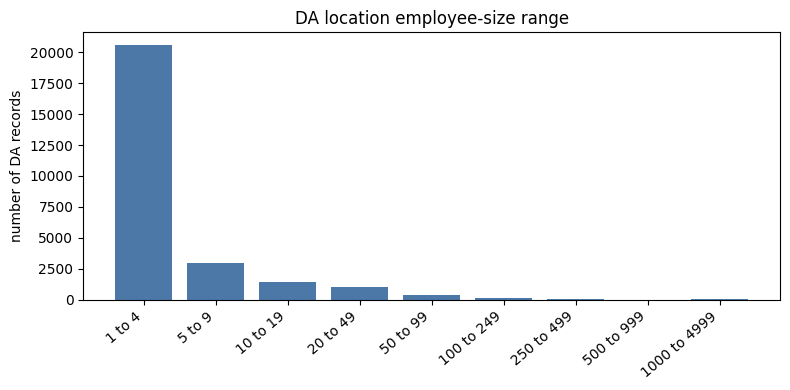

In [50]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(emp_range_order, emp_counts.values, color="#4C78A8")
ax.set_ylabel("number of DA records")
ax.set_title("DA location employee-size range")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.show()

**Takeaway:** ~70% of DA records report 1-4 employees at the location — Oakland's DA-listed
business population (once you count individually-listed practitioners) looks overwhelmingly like
microbusinesses. This is a plausible candidate metric (`microbusiness_share`) for a future
corridor profile, with the caveat that some of this is the same single-practitioner effect seen in
Section 5.

In [51]:
print(f"Missing 'Years In Database': {da_std['Years In Database'].isna().mean()*100:.1f}%")
print(f"Missing 'Year Established':  {da_std['Year Established'].isna().mean()*100:.1f}%")
print()
print("Years In Database summary:")
print(da_std["Years In Database"].describe().round(1))

Missing 'Years In Database': 0.0%
Missing 'Year Established':  74.7%

Years In Database summary:
count    29545.0
mean        12.7
std          9.8
min          1.0
25%          6.0
50%         10.0
75%         15.0
max         43.0
Name: Years In Database, dtype: float64


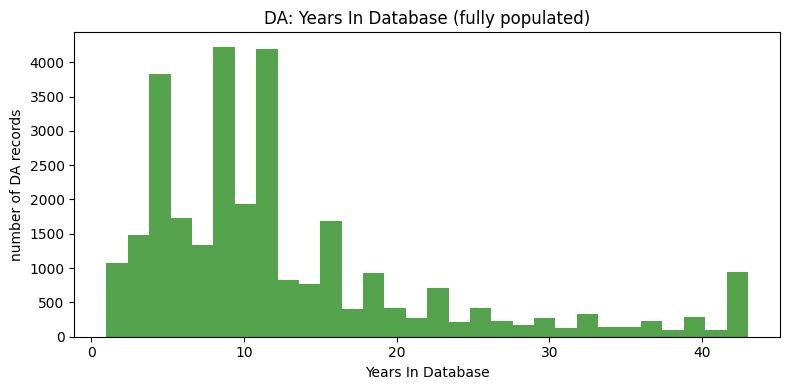

In [52]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(da_std["Years In Database"].dropna(), bins=30, color="#54A24B")
ax.set_xlabel("Years In Database")
ax.set_ylabel("number of DA records")
ax.set_title("DA: Years In Database (fully populated)")
plt.tight_layout()
plt.show()

**Takeaway:** as flagged back in Section 1, `Years In Database` is **fully populated** while
`Year Established` is **missing ~75% of the time** — for this file, `Years In Database` is the
usable longevity signal, and `Year Established` is too sparse to build a reliable metric on
without much more imputation.

In [53]:
sales_order = ["Less Than $500,000", "$500,000-1 Million", "$1-2.5 Million", "$2.5-5 Million",
               "$5-10 Million", "$10-20 Million", "$20-50 Million", "$50-100 Million",
               "$100-500 Million", "$500m - $1 Billion"]
sales_counts = da_std["Location Sales Volume Range"].value_counts().reindex(sales_order).fillna(0)
print(f"Missing sales-volume-range: {da_std['Location Sales Volume Range'].isna().mean()*100:.1f}%")
print((sales_counts / sales_counts.sum() * 100).round(1))

Missing sales-volume-range: 21.5%
Location Sales Volume Range
Less Than $500,000    69.3
$500,000-1 Million    12.5
$1-2.5 Million        10.6
$2.5-5 Million         3.7
$5-10 Million          2.2
$10-20 Million         1.0
$20-50 Million         0.5
$50-100 Million        0.1
$100-500 Million       0.1
$500m - $1 Billion     0.0
Name: count, dtype: float64


In [54]:
franchise_populated = da_std["Franchise Description 1"].notna()
print(f"'Franchise Description 1' populated: {franchise_populated.mean()*100:.1f}% of records")
print()
print("Most common values (note: many are medical specialties, not franchise brands):")
print(da_std["Franchise Description 1"].value_counts().head(10))
print()
multi_loc = da_std["Affiliated Locations"].fillna(0) > 0
print(f"Records with Affiliated Locations > 0 (plausible multi-location indicator): "
      f"{multi_loc.sum():,} ({multi_loc.mean()*100:.1f}%)")

'Franchise Description 1' populated: 13.5% of records

Most common values (note: many are medical specialties, not franchise brands):
Franchise Description 1
Internal Medicine     353
General Dentistry     252
Atm (Amex)            251
Pediatrics            250
Family Practice       198
Emergency Medicine    190
Surgery               116
Ob/Gyn                 87
Anesthesiology         86
Psychiatry             83
Name: count, dtype: int64

Records with Affiliated Locations > 0 (plausible multi-location indicator): 74 (0.3%)


**Takeaway:** despite its name, `Franchise Description 1` is dominated by **medical specialty
labels** ("Internal Medicine", "General Dentistry", "Pediatrics", ...), not retail/food franchise
brands — using it directly as a "franchise share" metric would be misleading without first
separating medical specialties from actual franchise/chain tags. `Affiliated Locations` /
`Affiliated Records` are a cleaner (if very sparse — nonzero for well under 1% of records)
multi-location signal.

In [55]:
credit_order = ["A+", "A", "B+", "B", "C+", "C", "P", "I", "U"]
credit_counts = da_std["Credit Score Alpha"].value_counts().reindex(credit_order)
print(f"Missing credit score: {da_std['Credit Score Alpha'].isna().mean()*100:.1f}%")
print(credit_counts)

Missing credit score: 0.0%
Credit Score Alpha
A+     536
A     1828
B+    6752
B     8621
C+    3386
C     2074
P      557
I     2388
U     3403
Name: count, dtype: int64


**Takeaway:** `Credit Score Alpha` is fully populated but includes non-informative categories
(`U` = unrated, `I` = presumably individual/insufficient data) that should be treated as "unknown"
rather than a real grade if this field is used later — roughly 1 in 5 records fall into one of
those two non-grade buckets.

## 15. Candidate Corridor/Map Metrics

A concise inventory of possible future corridor indicators, and whether the current two sources
support calculating each one today.

In [56]:
candidate_metrics = pd.DataFrame([
    ("Number of business entities", "BL, DA", "Yes", "raw record count", "Inflated wherever many entities share one address (Section 5)"),
    ("Number of unique physical business locations", "BL, DA", "Yes", "distinct address_base count", "Depends on address-normalization quality"),
    ("Businesses per km of corridor", "BL, DA + corridor geometry", "Partial", "entities or locations / corridor length", "Only computable for existing BID/Policy Polygon corridors, which are incomplete (Section 12)"),
    ("Consumer-facing businesses per km", "DA (+ relevance_class)", "Partial", "as above, consumer_facing subset only", "relevance_class is a first-pass heuristic, not validated (Section 6); BL has no equivalent flag"),
    ("Employee count / median employee size", "DA", "Yes", "Location Employee Size Range/Actual", "'Actual' column has many exact-looking values that may really be range midpoints"),
    ("Microbusiness share", "DA", "Yes", "% of records in '1 to 4' employee bucket", "~70% currently - partly a single-practitioner artifact (Section 5)"),
    ("Home-business share", "DA", "Yes", "% Home Business == Yes", "No equivalent flag exists in BL"),
    ("Franchise / chain share", "DA", "No (not cleanly)", "% with a genuine franchise/chain tag", "Franchise Description 1 conflates franchises with medical specialties (Section 14)"),
    ("Broad-sector shares", "BL, DA", "Yes", "% of records/locations per broad sector", "Each source has its own composition bias (Section 10)"),
    ("Sector diversity (e.g. entropy)", "BL, DA", "Yes", "computable from sector shares", "Not calculated in this notebook; straightforward extension"),
    ("Sector specialization / location quotient", "BL, DA", "Partial", "corridor sector share vs. citywide share", "Needs a defined corridor geometry; feasible once Section 13's density work matures"),
    ("Median years in database", "DA", "Yes", "Years In Database", "Fully populated (Section 14); no equivalent in BL"),
    ("Business-source agreement rate", "BL + DA", "Yes", "match rate from Section 7", "Sensitive to address-normalization choices"),
    ("Eventual openings", "D&B / time series", "No", "n/a", "Requires multi-period data not present in either current file"),
    ("Eventual closures", "D&B / time series", "No", "n/a", "Same as above"),
    ("Eventual churn", "D&B / time series", "No", "n/a", "Same as above"),
    ("Eventual relocation", "D&B / time series", "No", "n/a", "Same as above"),
    ("Eventual mobile-activity change", "D&B / other", "No", "n/a", "No mobility data present in either file"),
], columns=["metric", "source(s)", "can_calculate_now", "unit / definition", "important caveat"])
candidate_metrics

,metric,source(s),can_calculate_now,unit / definition,important caveat
0,Number of business entities,"BL, DA",Yes,raw record count,Inflated wherever many entities share one addr...
1,Number of unique physical business locations,"BL, DA",Yes,distinct address_base count,Depends on address-normalization quality
2,Businesses per km of corridor,"BL, DA + corridor geometry",Partial,entities or locations / corridor length,Only computable for existing BID/Policy Polygo...
3,Consumer-facing businesses per km,DA (+ relevance_class),Partial,"as above, consumer_facing subset only","relevance_class is a first-pass heuristic, not..."
4,Employee count / median employee size,DA,Yes,Location Employee Size Range/Actual,'Actual' column has many exact-looking values ...
5,Microbusiness share,DA,Yes,% of records in '1 to 4' employee bucket,~70% currently - partly a single-practitioner ...
6,Home-business share,DA,Yes,% Home Business == Yes,No equivalent flag exists in BL
7,Franchise / chain share,DA,No (not cleanly),% with a genuine franchise/chain tag,Franchise Description 1 conflates franchises w...
8,Broad-sector shares,"BL, DA",Yes,% of records/locations per broad sector,Each source has its own composition bias (Sect...
9,Sector diversity (e.g. entropy),"BL, DA",Yes,computable from sector shares,Not calculated in this notebook; straightforwa...


## 16. Proposed Structure for the Eventual Integrated Business Database

This section is a **proposal, not an implementation** — nothing below is built in this notebook.

The eventual goal is not to append BL, DA, and D&B into one long table, but to resolve them into
**canonical business entities**, each backed by evidence from whichever source(s) support it.
A rough conceptual schema:

```text
canonical_business_id        # stable ID for the resolved entity

business_name                # best-available name (DA/D&B only today - BL has none)
address                      # best-available full address string
base_address                 # normalized street address, no unit
unit                         # suite/unit, if any
latitude / longitude         # best-available coordinate
sector                       # broad sector (+ retained detailed NAICS/SIC per source)

in_data_axle                 # bool
in_business_license          # bool
in_dnb                       # bool (once available)

data_axle_id                 # source record key, if in_data_axle
business_license_id          # source record key, if in_business_license
dnb_id                       # source record key, if in_dnb

match_method                 # e.g. "exact_address", "spatial+address", "fuzzy", "manual"
match_score                  # similarity score behind the match, where applicable
match_confidence             # e.g. high / medium / low / needs_review
```

A few things this notebook's findings imply for that design:

- **Different attributes will legitimately come from different sources.** BL has no name field at
  all, so `business_name` will come from DA or D&B; DA has no license/permit status, so that would
  come from BL; longevity is best represented by DA's `Years In Database` rather than the sparser
  `Year Established`.
- **`match_confidence` needs to encode real uncertainty**, not just a numeric score — Section 7
  showed a large share of shared addresses are one-to-many or many-to-many, and Section 9 showed
  fuzzy scores alone don't cleanly separate true matches from false ones.
- **A canonical record need not require agreement across all three sources.** A BL-only rental
  registration and a DA-only home business are both legitimate canonical entities with
  `in_dnb = False` and, in the BL case, `in_data_axle = False` — the schema should support partial
  evidence gracefully rather than only capturing full three-way matches.

## Key Findings and Next Steps

**What a "record" means in each source.** BL is closest to "one licensed use at one address" and
includes no business name at all; roughly 56% of BL records are rental-property registrations
(NAICS "Lessors of ... Buildings"), not storefronts. DA is closest to "one establishment or
individually-listed practitioner," and a modest number of large medical buildings each contribute
hundreds of separate DA "businesses."

**Sector representation differs sharply and for identifiable reasons.** DA's ~37% Health Care &
Social Assistance share and BL's ~56% Finance/Insurance/Real Estate share are each driven by a
single dominant mechanism specific to that source (respectively: shared medical buildings, and
rental-property licensing) rather than reflecting Oakland's actual commercial mix.

**Establishments vs. unique locations matters, especially for DA.** DA averages ~1.95 records per
unique raw address (~2.7 once addresses are normalized to a common base street address) vs. BL's
~1.15-1.4; addresses with 5+ DA records skew toward ~59% Health Care versus ~37% overall,
confirming that raw DA counts overstate physical commercial presence in specific places.

**Home-business / corridor-relevance is only partially resolvable today.** DA's `Home Business`
flag (~10% of records) and a tentative sector-based `relevance_class` give a workable first-pass
split, but BL has no equivalent field, and the classification itself is unvalidated.

**Source overlap is moderate and lopsided.** About half of DA records match a BL address exactly
(rising to ~78% ignoring unit numbers); only ~19-33% of BL records find any DA match depending on
match strictness, mostly because BL is larger and includes many records (rental licenses) that
were never going to appear in a commercial database like DA.

**Address matching alone is not enough.** Only about 4 in 10 shared addresses are clean one-to-one
matches; the rest are one-to-many or many-to-many, meaning any future matching step needs a
tie-breaker beyond address equality (ultimately, business name and/or D&B evidence).

**Spatial proximity adds real information, but the two signals disagree more than expected.** ~55%
of DA records land in the clean "address match + spatially close" bucket, but "address match, yet
coordinates far apart" (22%) is actually larger than "no address match, but spatially close" (18%)
— textual address agreement does not reliably imply coordinate agreement, and vice versa, so
neither signal should be trusted alone.

**A large share of business activity sits outside the existing BID/Policy Polygon boundaries.**
Density mapping shows clear corridor-like concentrations beyond the current polygons (parts of
International Blvd/East 14th, MacArthur Blvd, Foothill Blvd), consistent with the brief's premise
that these shapefiles are an incomplete picture of Oakland's commercial geography.

**Fuzzy matching exposed a specific, important failure mode, not just a score distribution.**
Several score >=95 "high-confidence" pairs turned out to be different house numbers on the same
street (e.g. `825` vs. `725 International Blvd`) — plain string similarity is easily fooled when a
long, identical street name dominates the score and swamps a one-digit house-number difference.
Fuzzy address score alone is not trustworthy evidence of a match; it needs corroboration
(coordinate proximity, eventually business name).

**What wasn't possible or reliable here, due to missing/incomplete fields:**

- No name-based matching, because BL has no business-name field at all.
- No franchise/chain-share metric, because `Franchise Description 1` conflates franchise brands
  with medical specialties.
- No `Year Established`-based longevity metric at scale, because it's ~75% missing (use
  `Years In Database` instead).
- No openings/closures/churn/relocation/mobile-activity metrics, because both files are single
  snapshots with no temporal or multi-period structure.
- No fully validated consumer-facing/home-based classification, because it currently rests on
  NAICS sector plus a couple of DA-only flags rather than ground-truthed labels.

**Once D&B arrives**, the priority should be: (1) confirm whether it provides a usable business
name and richer temporal fields (openings/closures) that neither current source has; (2) re-run
the address/spatial/fuzzy matching hierarchy from Sections 7-9 three ways instead of two; (3) use
D&B to help adjudicate the one-to-many / many-to-many address situations that BL-DA matching alone
cannot resolve; and (4) begin building the canonical schema in Section 16 as an actual table, with
`match_method` / `match_confidence` populated from this notebook's methodology rather than assumed.
